# PROJETO DE CREDIT SCORING - QUANTUM FINANCE
## MBA em Data Science & Artificial Intelligence - Applied Statistics

### Objetivo
Desenvolver um modelo preditivo de credit scoring utilizando regressão linear múltipla para prever o **SCORE_CREDITO** dos clientes.



In [1]:
# Importação de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, mannwhitneyu
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Importações de diagnóstico do statsmodels (localizações podem variar por versão)
try:
    from statsmodels.stats.diagnostic import het_breuschpagan
except ImportError:
    het_breuschpagan = None

from statsmodels.stats.stattools import durbin_watson

# Configurações de visualização
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('seaborn')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [52]:
# Carregamento dos dados
df = pd.read_csv("./Base_ScoreCredito_QuantumFinance.csv", sep=";", decimal=",")
df["id"] = df["id"].astype(str)
df = df.set_index("id")
print(f"Shape do dataset: {df.shape}")
print(f"\nPrimeiras linhas:")
df.head()

Shape do dataset: (10127, 14)

Primeiras linhas:


,idade,sexo,estado_civil,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
id,,,,,,,,,,,,,,
708082083,45,F,casado,graduacao,3,40,1,40.089665,3,0,0,1,1,778.0
708083283,58,M,solteiro,ensino fundam,0,44,1,66.557645,3,0,0,1,0,276.3
708084558,46,M,divorciado,doutorado,3,35,1,123.681821,6,0,0,1,1,401.0
708085458,34,F,solteiro,mestrado,0,22,1,19.715934,6,0,0,1,0,347.4
708086958,49,F,casado,mestrado,2,36,0,0.000000,3,1,437,1,2,476.0


In [53]:
# Informações gerais do dataset
print("Informações do dataset:")
print(df.info())
print("\n" + "="*50)
print("\nTipos de dados:")
print(df.dtypes)


Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 10127 entries, 708082083 to 828343083
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   idade                10127 non-null  int64  
 1   sexo                 10127 non-null  object 
 2   estado_civil         10127 non-null  object 
 3   escola               10127 non-null  object 
 4   Qte_dependentes      10127 non-null  int64  
 5   tempo_ultimoservico  10127 non-null  int64  
 6   trabalha             10127 non-null  int64  
 7   vl_salario_mil       10127 non-null  float64
 8   reg_moradia          10127 non-null  int64  
 9   casa_propria         10127 non-null  int64  
 10  vl_imovel_em_mil     10127 non-null  int64  
 11  Qte_cartoes          10127 non-null  int64  
 12  Qte_carros           10127 non-null  int64  
 13  SCORE_CREDITO        10127 non-null  float64
dtypes: float64(2), int64(9), object(3)
memory usage: 1.2+ M

## 1. ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

### 1.1 Análise Descritiva Univariada


In [54]:
# Estatísticas descritivas para variáveis numéricas
variaveis_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
# Remover 'id' das análises (se presente)
if 'id' in variaveis_numericas:
    variaveis_numericas.remove('id')
print("Estatísticas descritivas das variáveis numéricas:")
print("="*80)
df[variaveis_numericas].describe()


Estatísticas descritivas das variáveis numéricas:


,idade,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,1.547447,34.133208,0.911919,70.209002,3.783450,0.352424,208.999111,1.083638,0.623383,469.500364
std,8.016814,1.489079,8.221428,0.283427,55.567032,1.580486,0.477749,378.495229,0.333784,0.569796,133.814653
min,26.000000,0.000000,7.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,162.000000
25%,41.000000,0.000000,30.000000,1.000000,21.330536,3.000000,0.000000,0.000000,1.000000,0.000000,375.000000
50%,46.000000,1.000000,34.000000,1.000000,66.486331,4.000000,0.000000,0.000000,1.000000,1.000000,449.600000
75%,52.000000,3.000000,39.000000,1.000000,107.544225,5.000000,1.000000,289.000000,1.000000,1.000000,540.900000
max,73.000000,5.000000,57.000000,1.000000,233.301793,6.000000,1.000000,1800.000000,4.000000,2.000000,979.650000


In [55]:
# Análise da variável target SCORE_CREDITO
print("Análise da variável target SCORE_CREDITO:")
print("="*50)
print(f"Média: {df['SCORE_CREDITO'].mean():.2f}")
print(f"Mediana: {df['SCORE_CREDITO'].median():.2f}")
print(f"Desvio Padrão: {df['SCORE_CREDITO'].std():.2f}")
print(f"Mínimo: {df['SCORE_CREDITO'].min():.2f}")
print(f"Máximo: {df['SCORE_CREDITO'].max():.2f}")
print(f"Q1 (25%): {df['SCORE_CREDITO'].quantile(0.25):.2f}")
print(f"Q3 (75%): {df['SCORE_CREDITO'].quantile(0.75):.2f}")
print(f"Assimetria: {df['SCORE_CREDITO'].skew():.2f}")
print(f"Curtose: {df['SCORE_CREDITO'].kurtosis():.2f}")


Análise da variável target SCORE_CREDITO:
Média: 469.50
Mediana: 449.60
Desvio Padrão: 133.81
Mínimo: 162.00
Máximo: 979.65
Q1 (25%): 375.00
Q3 (75%): 540.90
Assimetria: 0.71
Curtose: 0.29


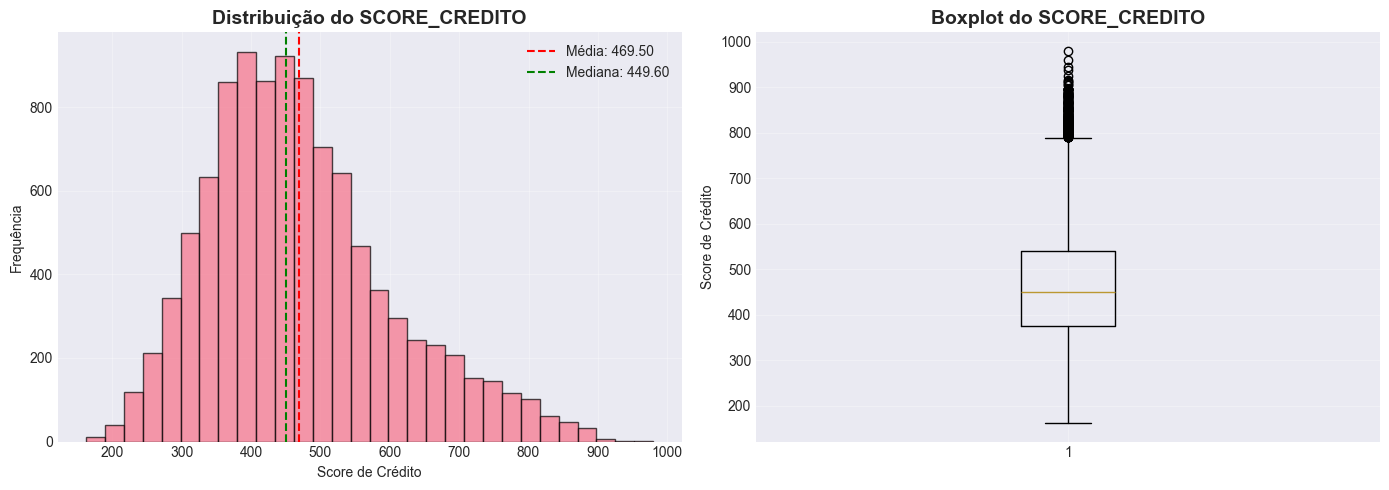

In [56]:
# Histograma e boxplot da variável target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['SCORE_CREDITO'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(df['SCORE_CREDITO'].mean(), color='red', linestyle='--', 
                label=f'Média: {df["SCORE_CREDITO"].mean():.2f}')
axes[0].axvline(df['SCORE_CREDITO'].median(), color='green', linestyle='--', 
                label=f'Mediana: {df["SCORE_CREDITO"].median():.2f}')
axes[0].set_title('Distribuição do SCORE_CREDITO', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Score de Crédito')
axes[0].set_ylabel('Frequência')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(df['SCORE_CREDITO'], vert=True)
axes[1].set_title('Boxplot do SCORE_CREDITO', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score de Crédito')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [57]:
# Verificação de outliers usando método IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("Detecção de outliers nas variáveis numéricas:")
print("="*60)
for var in variaveis_numericas:
    outliers, lower, upper = detect_outliers_iqr(df, var)
    print(f"\n{var}:")
    print(f"  Limites: [{lower:.2f}, {upper:.2f}]")
    print(f"  Número de outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")


Detecção de outliers nas variáveis numéricas:

idade:
  Limites: [24.50, 68.50]
  Número de outliers: 2 (0.02%)

Qte_dependentes:
  Limites: [-4.50, 7.50]
  Número de outliers: 0 (0.00%)

tempo_ultimoservico:
  Limites: [16.50, 52.50]
  Número de outliers: 427 (4.22%)

trabalha:
  Limites: [1.00, 1.00]
  Número de outliers: 892 (8.81%)

vl_salario_mil:
  Limites: [-107.99, 236.86]
  Número de outliers: 0 (0.00%)

reg_moradia:
  Limites: [0.00, 8.00]
  Número de outliers: 0 (0.00%)

casa_propria:
  Limites: [-1.50, 2.50]
  Número de outliers: 0 (0.00%)

vl_imovel_em_mil:
  Limites: [-433.50, 722.50]
  Número de outliers: 1095 (10.81%)

Qte_cartoes:
  Limites: [1.00, 1.00]
  Número de outliers: 691 (6.82%)

Qte_carros:
  Limites: [-1.50, 2.50]
  Número de outliers: 0 (0.00%)

SCORE_CREDITO:
  Limites: [126.15, 789.75]
  Número de outliers: 248 (2.45%)


In [58]:
# Distribuição de frequências das variáveis categóricas
variaveis_categoricas = df.select_dtypes(include=['object']).columns.tolist()
print("Variáveis categóricas encontradas:", variaveis_categoricas)

for var in variaveis_categoricas:
    print(f"\n{'='*60}")
    print(f"Distribuição de frequências - {var}")
    print('='*60)
    freq = df[var].value_counts()
    freq_pct = df[var].value_counts(normalize=True) * 100
    freq_df = pd.DataFrame({
        'Frequência': freq,
        'Percentual (%)': freq_pct
    })
    print(freq_df)


Variáveis categóricas encontradas: ['sexo', 'estado_civil', 'escola']

Distribuição de frequências - sexo
      Frequência  Percentual (%)
sexo                            
F           5358       52.908068
M           4769       47.091932

Distribuição de frequências - estado_civil
              Frequência  Percentual (%)
estado_civil                            
casado              4687       46.282216
solteiro            3943       38.935519
na                   749        7.396070
divorciado           748        7.386195

Distribuição de frequências - escola
               Frequência  Percentual (%)
escola                                   
ensino medio         3352       33.099635
ensino fundam        2283       22.543695
graduacao            2094       20.677397
mestrado             1639       16.184457
doutorado             759        7.494816


### 1.2 Análise de Dados Faltantes


In [59]:
# Análise de dados faltantes
missing_data = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Valores Faltantes': missing_data,
    'Percentual (%)': missing_pct
})
missing_df = missing_df[missing_df['Valores Faltantes'] > 0].sort_values('Valores Faltantes', ascending=False)

if len(missing_df) > 0:
    print("Variáveis com dados faltantes:")
    print("="*50)
    print(missing_df)
else:
    print("Não há dados faltantes no dataset!")


Não há dados faltantes no dataset!


### 1.3 Visualizações Gráficas


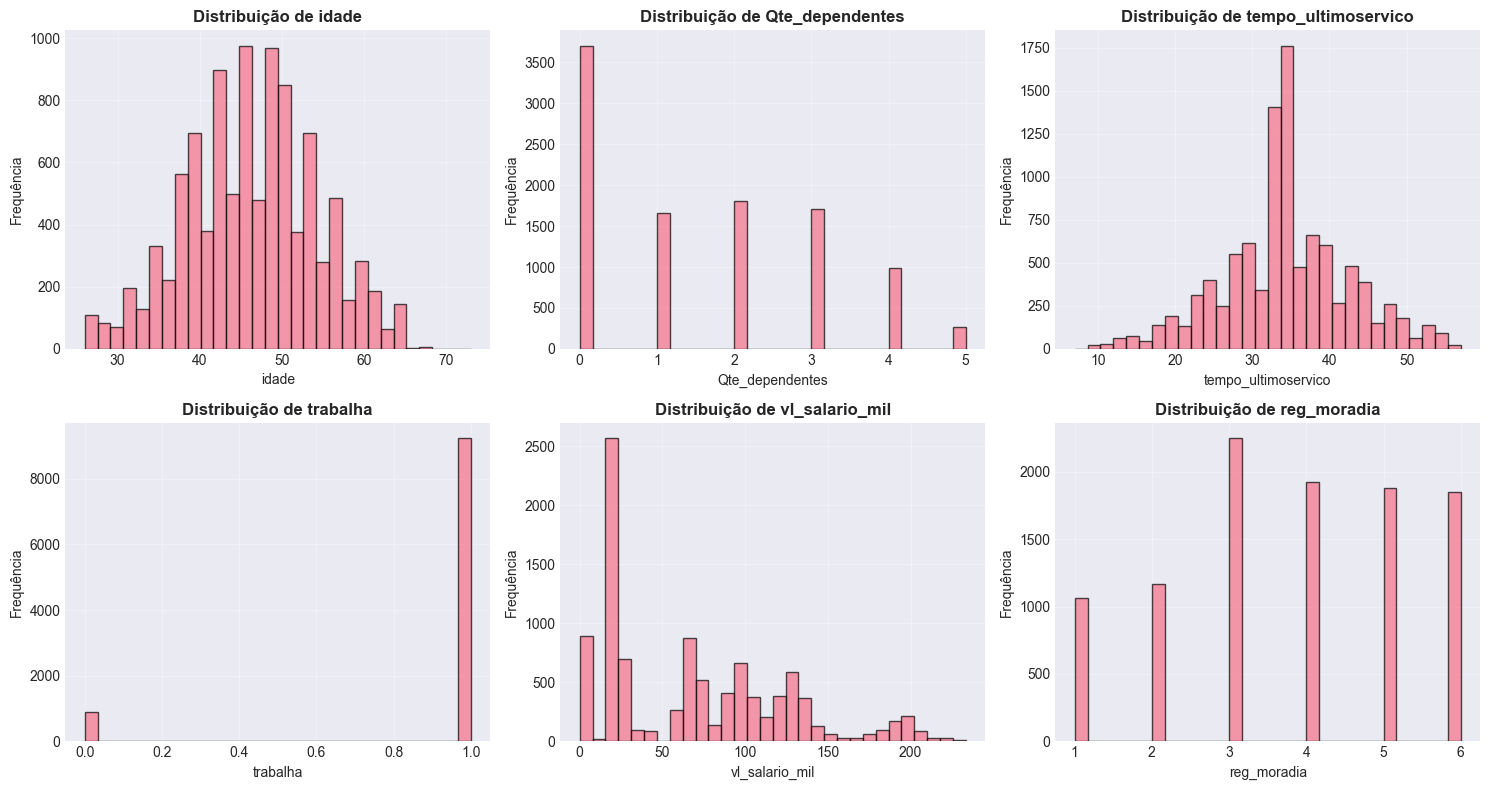

In [60]:
# Histogramas para variáveis numéricas principais
n_vars = len(variaveis_numericas[:6])  # Primeiras 6 variáveis numéricas
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for idx, var in enumerate(variaveis_numericas[:6]):
    axes[idx].hist(df[var].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribuição de {var}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Frequência')
    axes[idx].grid(True, alpha=0.3)

# Remover subplots vazios
for idx in range(n_vars, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


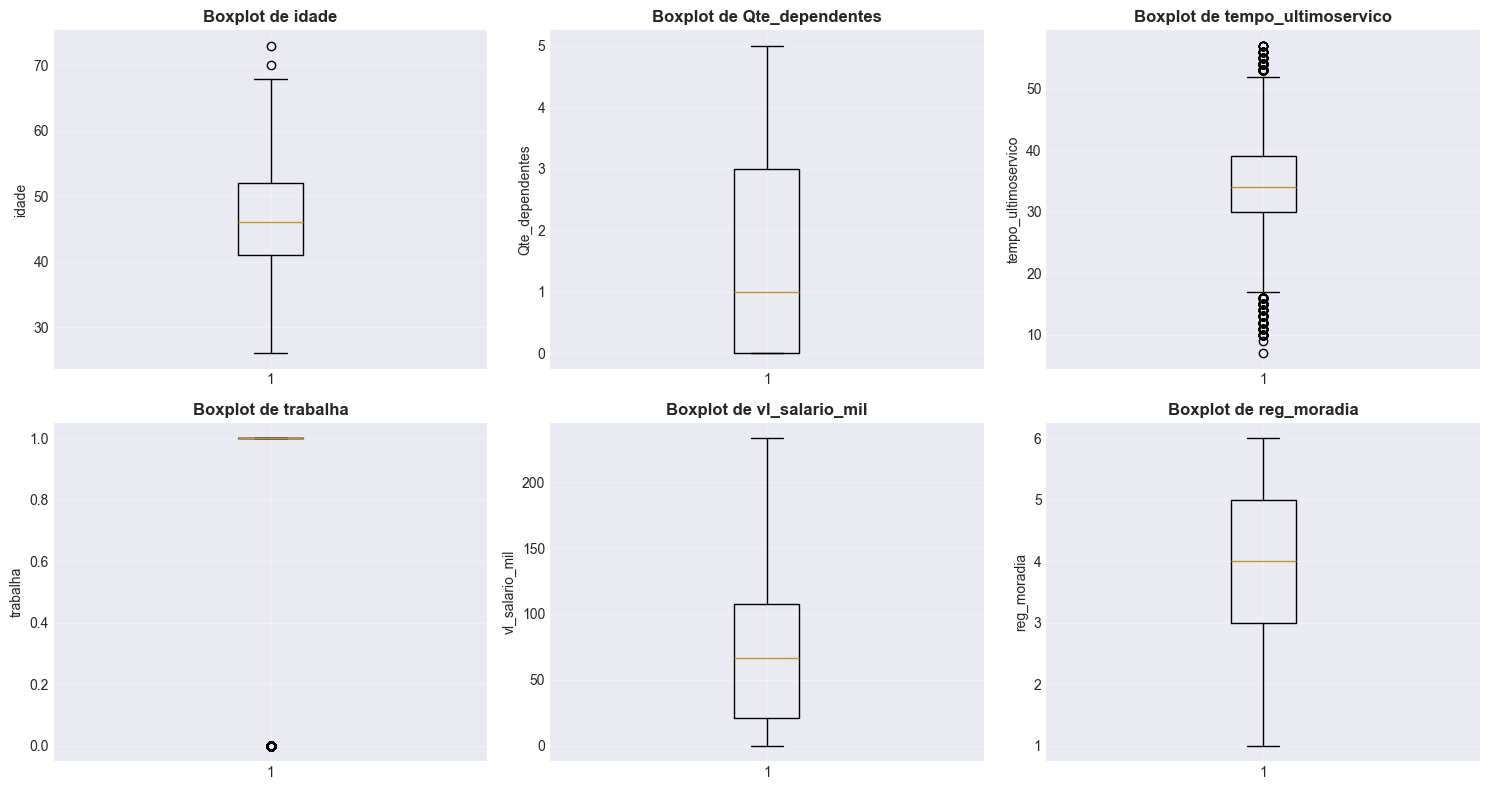

In [61]:
# Boxplots para variáveis numéricas principais
n_vars = len(variaveis_numericas[:6])
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for idx, var in enumerate(variaveis_numericas[:6]):
    axes[idx].boxplot(df[var].dropna(), vert=True)
    axes[idx].set_title(f'Boxplot de {var}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(var)
    axes[idx].grid(True, alpha=0.3)

for idx in range(n_vars, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


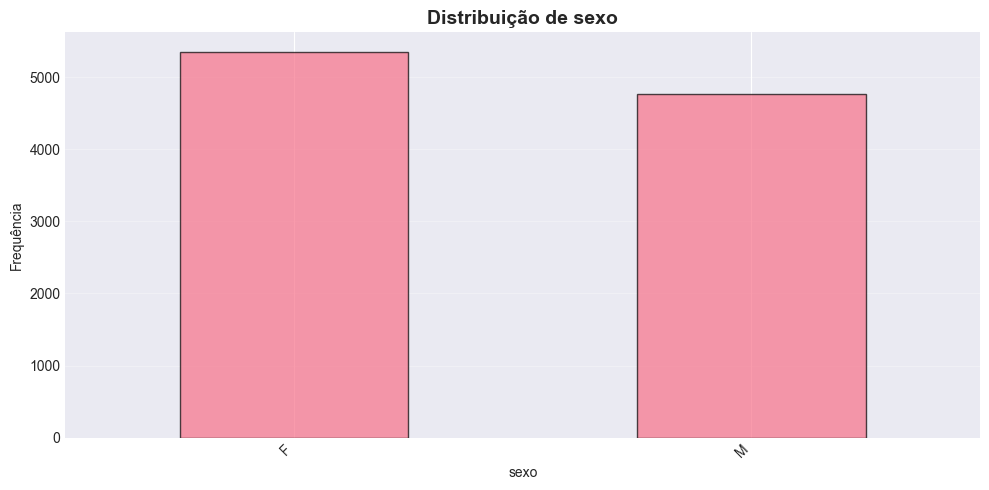

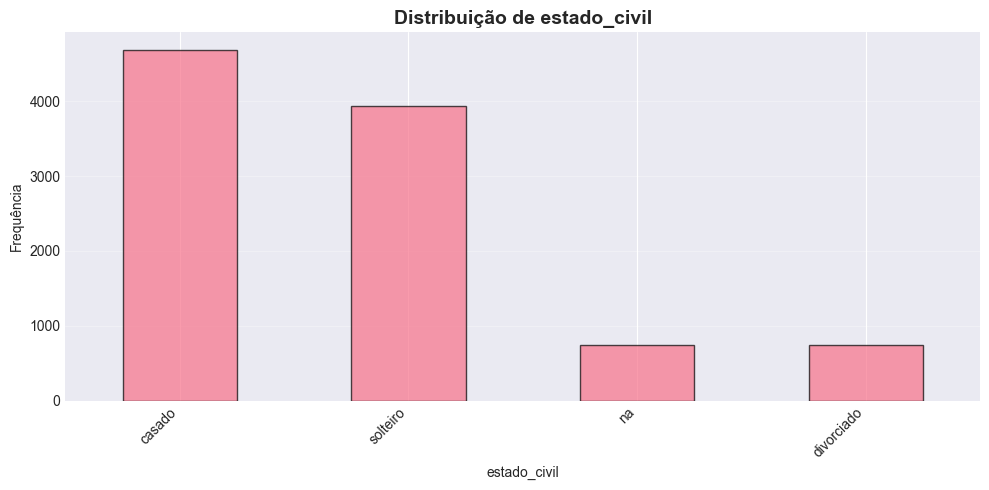

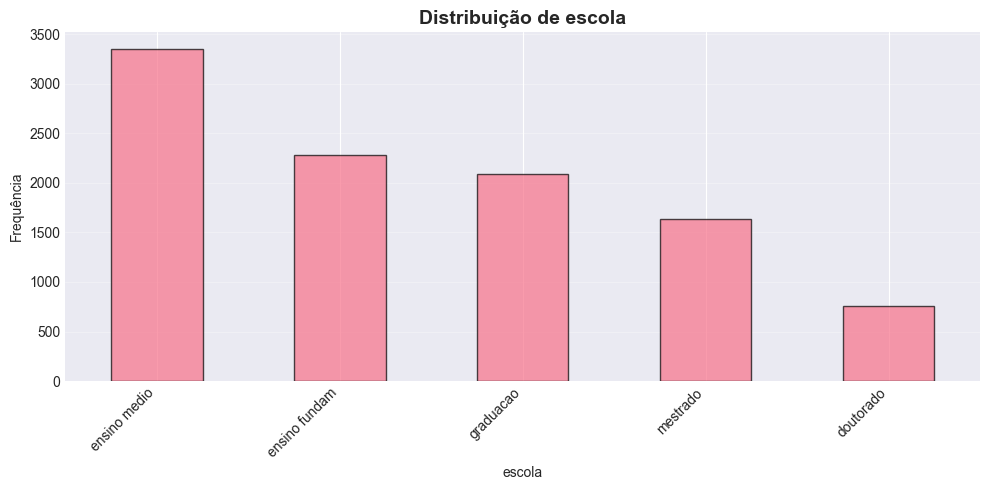

In [62]:
# Gráficos de barras para variáveis categóricas
for var in variaveis_categoricas:
    plt.figure(figsize=(10, 5))
    df[var].value_counts().plot(kind='bar', edgecolor='black', alpha=0.7)
    plt.title(f'Distribuição de {var}', fontsize=14, fontweight='bold')
    plt.xlabel(var)
    plt.ylabel('Frequência')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


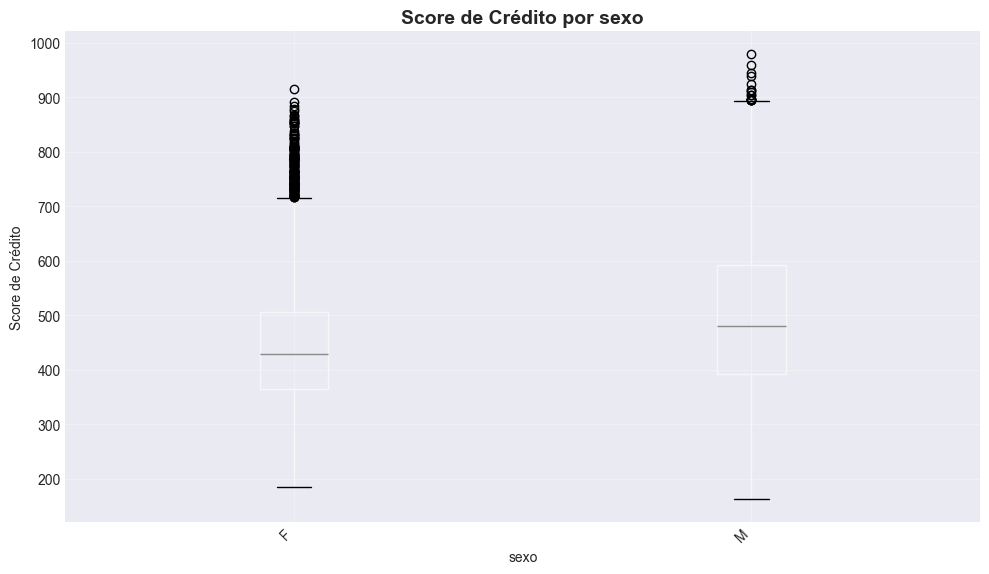

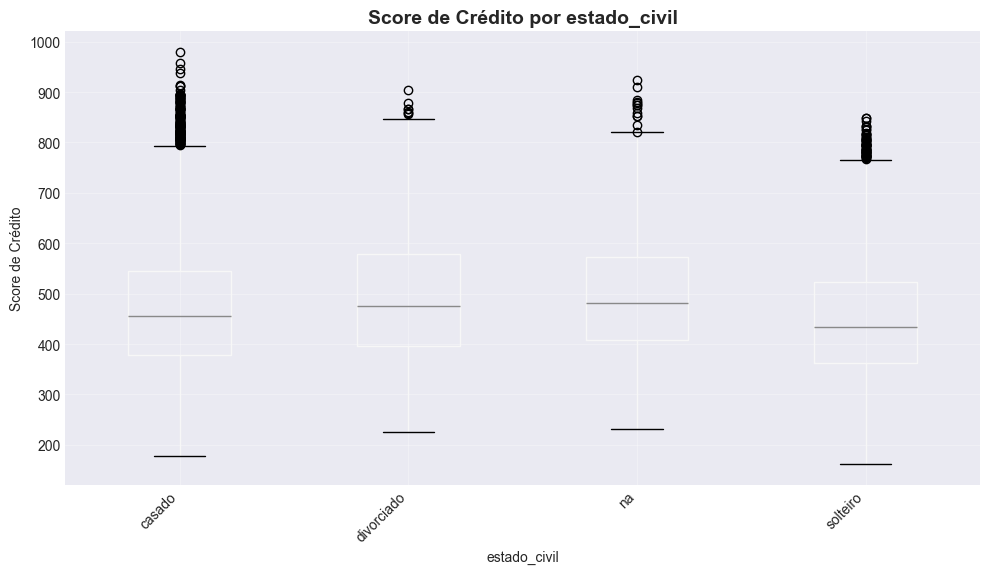

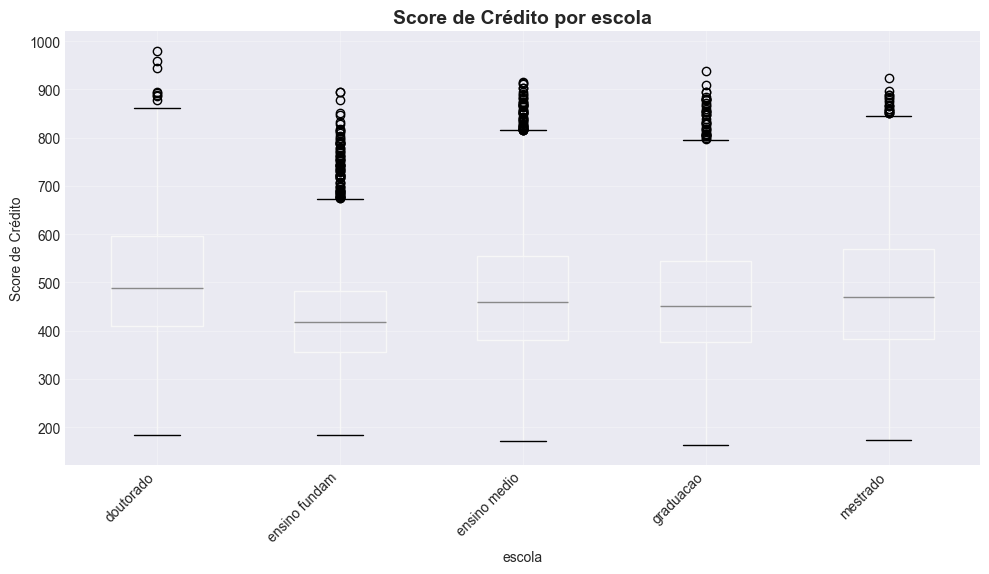

In [63]:
# Distribuição do score de crédito por segmentos categóricos
for var in variaveis_categoricas:
    plt.figure(figsize=(10, 6))
    df.boxplot(column='SCORE_CREDITO', by=var, ax=plt.gca())
    plt.title(f'Score de Crédito por {var}', fontsize=14, fontweight='bold')
    plt.suptitle('')  # Remove título automático
    plt.xlabel(var)
    plt.ylabel('Score de Crédito')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 2. TESTE DE HIPÓTESE E INTERVALO DE CONFIANÇA

### 2.1 Teste de Hipótese para Diferença de Médias


Estatísticas descritivas por grupo:
Com casa própria (n=3569):
  Média: 514.78
  Desvio Padrão: 151.60

Sem casa própria (n=6558):
  Média: 444.86
  Desvio Padrão: 115.86


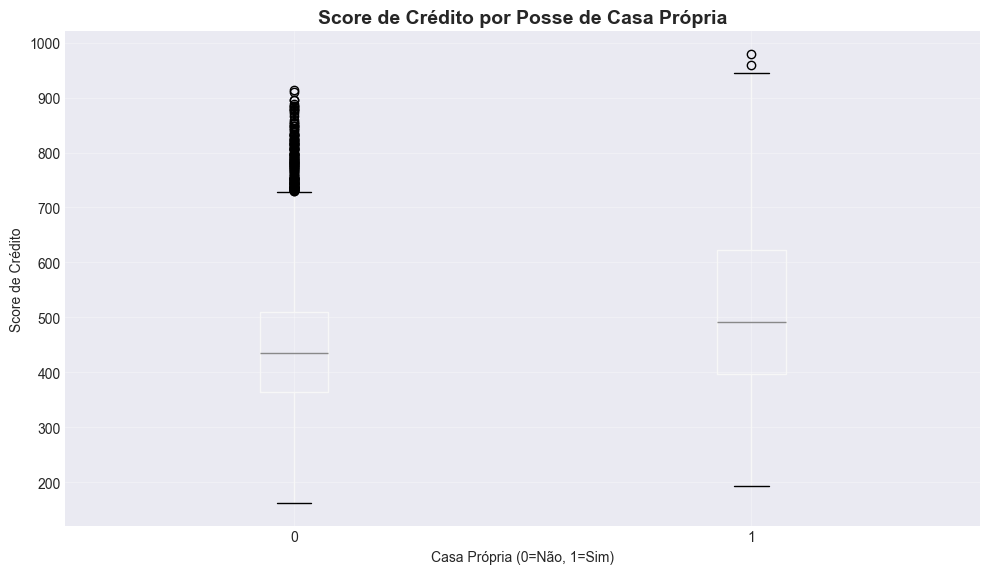

In [64]:
# Teste de hipótese: Score de crédito entre clientes com e sem casa própria
# H₀: μ₁ = μ₂ (Não há diferença significativa)
# H₁: μ₁ ≠ μ₂ (Há diferença significativa)

grupo_com_casa = df[df['casa_propria'] == 1]['SCORE_CREDITO']
grupo_sem_casa = df[df['casa_propria'] == 0]['SCORE_CREDITO']

print("Estatísticas descritivas por grupo:")
print("="*60)
print(f"Com casa própria (n={len(grupo_com_casa)}):")
print(f"  Média: {grupo_com_casa.mean():.2f}")
print(f"  Desvio Padrão: {grupo_com_casa.std():.2f}")
print(f"\nSem casa própria (n={len(grupo_sem_casa)}):")
print(f"  Média: {grupo_sem_casa.mean():.2f}")
print(f"  Desvio Padrão: {grupo_sem_casa.std():.2f}")

# Visualização
plt.figure(figsize=(10, 6))
df.boxplot(column='SCORE_CREDITO', by='casa_propria', ax=plt.gca())
plt.title('Score de Crédito por Posse de Casa Própria', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Casa Própria (0=Não, 1=Sim)')
plt.ylabel('Score de Crédito')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [65]:
# Teste de normalidade (Shapiro-Wilk)
print("Teste de Normalidade (Shapiro-Wilk):")
print("="*60)
alpha = 0.05

stat_com_casa, p_com_casa = shapiro(grupo_com_casa.sample(min(5000, len(grupo_com_casa))))
stat_sem_casa, p_sem_casa = shapiro(grupo_sem_casa.sample(min(5000, len(grupo_sem_casa))))

print(f"Grupo com casa própria:")
print(f"  Estatística: {stat_com_casa:.4f}")
print(f"  p-valor: {p_com_casa:.4f}")
print(f"  Normalidade: {'Sim' if p_com_casa > alpha else 'Não'} (α={alpha})")

print(f"\nGrupo sem casa própria:")
print(f"  Estatística: {stat_sem_casa:.4f}")
print(f"  p-valor: {p_sem_casa:.4f}")
print(f"  Normalidade: {'Sim' if p_sem_casa > alpha else 'Não'} (α={alpha})")

# Decisão sobre qual teste usar
if p_com_casa > alpha and p_sem_casa > alpha:
    print("\n✓ Ambos os grupos apresentam distribuição normal")
    print("→ Usar teste t independente")
    usar_teste_t = True
else:
    print("\n✗ Pelo menos um grupo não apresenta distribuição normal")
    print("→ Usar teste de Mann-Whitney (não paramétrico)")
    usar_teste_t = False


Teste de Normalidade (Shapiro-Wilk):
Grupo com casa própria:
  Estatística: 0.9729
  p-valor: 0.0000
  Normalidade: Não (α=0.05)

Grupo sem casa própria:
  Estatística: 0.9763
  p-valor: 0.0000
  Normalidade: Não (α=0.05)

✗ Pelo menos um grupo não apresenta distribuição normal
→ Usar teste de Mann-Whitney (não paramétrico)


In [66]:
# Realização do teste apropriado
print("\n" + "="*60)
print("TESTE DE HIPÓTESE")
print("="*60)
print(f"H₀: μ₁ = μ₂ (Não há diferença significativa no score de crédito médio)")
print(f"H₁: μ₁ ≠ μ₂ (Há diferença significativa no score de crédito médio)")
print(f"Nível de significância: α = {alpha}")

if usar_teste_t:
    # Teste t independente
    stat, p_value = stats.ttest_ind(grupo_com_casa, grupo_sem_casa)
    teste_usado = "Teste t independente"
else:
    # Teste de Mann-Whitney
    stat, p_value = mannwhitneyu(grupo_com_casa, grupo_sem_casa, alternative='two-sided')
    teste_usado = "Teste de Mann-Whitney"

print(f"\nTeste utilizado: {teste_usado}")
print(f"Estatística do teste: {stat:.4f}")
print(f"p-valor: {p_value:.6f}")

# Decisão
if p_value < alpha:
    print(f"\n✓ Rejeitamos H₀ (p-valor < {alpha})")
    print("Conclusão: Há diferença significativa no score de crédito médio entre os grupos")
else:
    print(f"\n✗ Não rejeitamos H₀ (p-valor ≥ {alpha})")
    print("Conclusão: Não há evidência suficiente de diferença significativa entre os grupos")



TESTE DE HIPÓTESE
H₀: μ₁ = μ₂ (Não há diferença significativa no score de crédito médio)
H₁: μ₁ ≠ μ₂ (Há diferença significativa no score de crédito médio)
Nível de significância: α = 0.05

Teste utilizado: Teste de Mann-Whitney
Estatística do teste: 14764619.5000
p-valor: 0.000000

✓ Rejeitamos H₀ (p-valor < 0.05)
Conclusão: Há diferença significativa no score de crédito médio entre os grupos


### 2.2 Intervalo de Confiança


In [67]:
# Intervalo de confiança de 95% para a média do score de crédito
confidence_level = 0.95
alpha_ic = 1 - confidence_level
n = len(df['SCORE_CREDITO'])
media = df['SCORE_CREDITO'].mean()
std = df['SCORE_CREDITO'].std()
sem = std / np.sqrt(n)  # Erro padrão da média

# Intervalo de confiança usando distribuição t
t_critical = stats.t.ppf(1 - alpha_ic/2, df=n-1)
ic_inferior = media - t_critical * sem
ic_superior = media + t_critical * sem

print("Intervalo de Confiança para a Média do Score de Crédito")
print("="*60)
print(f"Nível de confiança: {confidence_level*100}%")
print(f"Tamanho da amostra: {n}")
print(f"Média amostral: {media:.2f}")
print(f"Desvio padrão: {std:.2f}")
print(f"Erro padrão da média: {sem:.4f}")
print(f"\nIntervalo de Confiança:")
print(f"  [{ic_inferior:.2f}, {ic_superior:.2f}]")
print(f"\nInterpretação:")
print(f"Com {confidence_level*100}% de confiança, podemos afirmar que a média")
print(f"populacional do score de crédito está entre {ic_inferior:.2f} e {ic_superior:.2f}.")


Intervalo de Confiança para a Média do Score de Crédito
Nível de confiança: 95.0%
Tamanho da amostra: 10127
Média amostral: 469.50
Desvio padrão: 133.81
Erro padrão da média: 1.3297

Intervalo de Confiança:
  [466.89, 472.11]

Interpretação:
Com 95.0% de confiança, podemos afirmar que a média
populacional do score de crédito está entre 466.89 e 472.11.


## 3. ANÁLISE DE CORRELAÇÃO

### 3.1 Matriz de Correlação


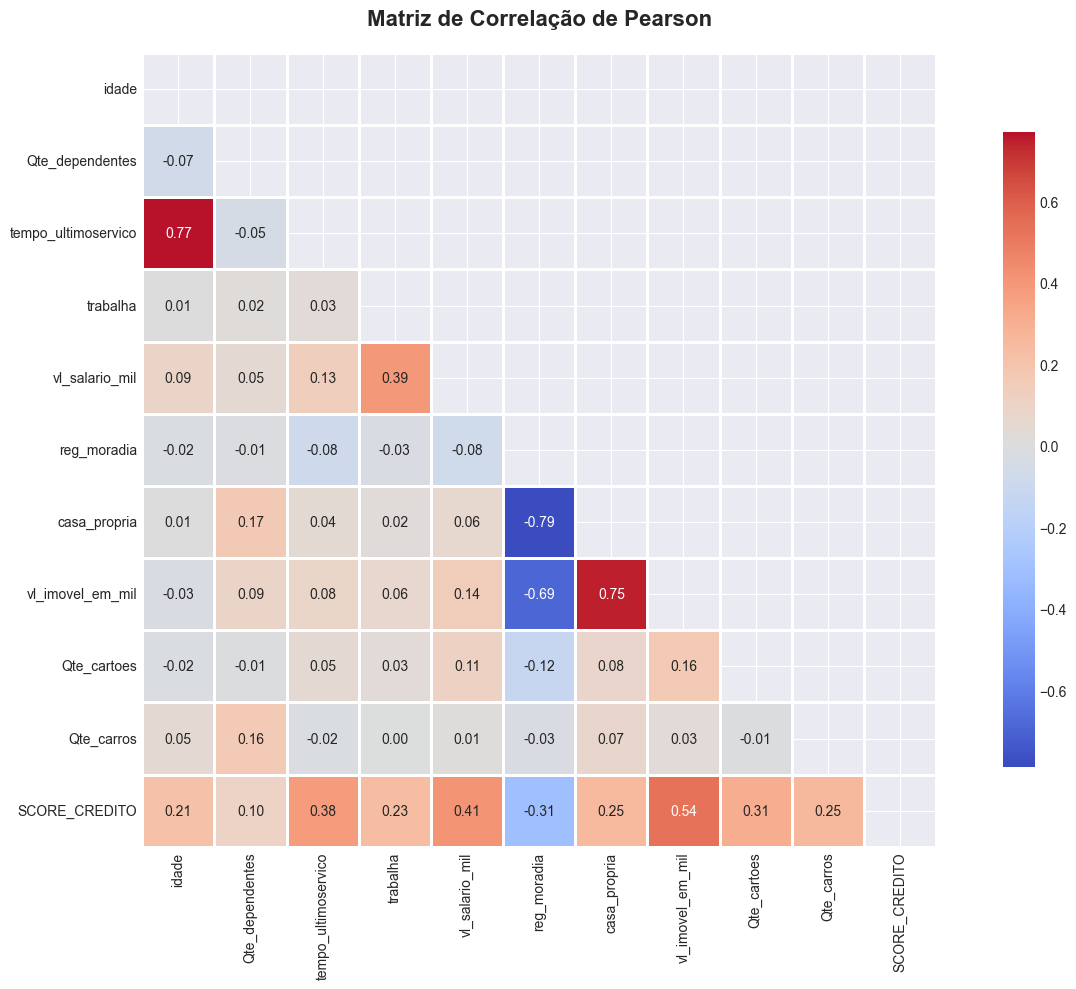

In [68]:
# Matriz de correlação de Pearson
correlation_matrix = df[variaveis_numericas].corr()

# Heatmap da matriz de correlação
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Máscara para mostrar apenas triângulo inferior
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação de Pearson', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


In [69]:
# Identificar correlações altas (|r| > 0.7)
print("Correlações altas (|r| > 0.7):")
print("="*60)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            high_corr_pairs.append({
                'Variável 1': correlation_matrix.columns[i],
                'Variável 2': correlation_matrix.columns[j],
                'Correlação': corr_value
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df.to_string(index=False))
    print("\n⚠ Atenção: Variáveis com alta correlação podem indicar multicolinearidade!")
else:
    print("Não foram encontradas correlações altas (|r| > 0.7) entre as variáveis.")


Correlações altas (|r| > 0.7):
  Variável 1          Variável 2  Correlação
       idade tempo_ultimoservico    0.768790
 reg_moradia        casa_propria   -0.789461
casa_propria    vl_imovel_em_mil    0.748545

⚠ Atenção: Variáveis com alta correlação podem indicar multicolinearidade!


In [70]:
# Correlações com a variável target
corr_target = correlation_matrix['SCORE_CREDITO'].sort_values(ascending=False)
print("Correlações com SCORE_CREDITO:")
print("="*60)
for var, corr in corr_target.items():
    if var != 'SCORE_CREDITO':
        print(f"{var:30s}: {corr:7.4f}")


Correlações com SCORE_CREDITO:
vl_imovel_em_mil              :  0.5373
vl_salario_mil                :  0.4141
tempo_ultimoservico           :  0.3840
Qte_cartoes                   :  0.3105
Qte_carros                    :  0.2530
casa_propria                  :  0.2496
trabalha                      :  0.2346
idade                         :  0.2133
Qte_dependentes               :  0.1036
reg_moradia                   : -0.3105


### 3.2 Análise de Associação


In [71]:
# ANOVA para testar diferenças de médias entre grupos categóricos
from scipy.stats import f_oneway

print("ANOVA - Teste de diferença de médias entre grupos categóricos")
print("="*60)

for var in variaveis_categoricas:
    grupos = [group['SCORE_CREDITO'].values for name, group in df.groupby(var)]
    f_stat, p_value = f_oneway(*grupos)
    
    print(f"\nVariável: {var}")
    print(f"  F-estatística: {f_stat:.4f}")
    print(f"  p-valor: {p_value:.6f}")
    
    if p_value < 0.05:
        print(f"  ✓ Há diferença significativa entre os grupos (p < 0.05)")
    else:
        print(f"  ✗ Não há evidência de diferença significativa (p ≥ 0.05)")
    
    # Estatísticas por grupo
    print(f"  Médias por grupo:")
    for name, group in df.groupby(var):
        print(f"    {name}: {group['SCORE_CREDITO'].mean():.2f}")


ANOVA - Teste de diferença de médias entre grupos categóricos

Variável: sexo
  F-estatística: 504.1448
  p-valor: 0.000000
  ✓ Há diferença significativa entre os grupos (p < 0.05)
  Médias por grupo:
    F: 442.01
    M: 500.39

Variável: estado_civil
  F-estatística: 52.7251
  p-valor: 0.000000
  ✓ Há diferença significativa entre os grupos (p < 0.05)
  Médias por grupo:
    casado: 476.34
    divorciado: 494.78
    na: 500.20
    solteiro: 450.75

Variável: escola
  F-estatística: 80.5498
  p-valor: 0.000000
  ✓ Há diferença significativa entre os grupos (p < 0.05)
  Médias por grupo:
    doutorado: 510.09
    ensino fundam: 429.60
    ensino medio: 477.59
    graduacao: 471.99
    mestrado: 486.56


## 4. PRÉ-PROCESSAMENTO DOS DADOS

### 4.1 Tratamento de Dados Faltantes


In [72]:
# Criar cópia do dataset para pré-processamento
df_processed = df.copy()

# Estratégia de tratamento de dados faltantes
# (Ajustar conforme análise exploratória anterior)
print("Tratamento de dados faltantes:")
print("="*60)

# Exemplo: Se houver dados faltantes, podemos usar imputação
# Para variáveis numéricas: média ou mediana
# Para variáveis categóricas: moda

# Verificar novamente dados faltantes
missing_before = df_processed.isnull().sum().sum()
print(f"Dados faltantes antes do tratamento: {missing_before}")

# Implementar estratégias conforme necessário
# Exemplo de imputação (descomentar se necessário):
# for col in variaveis_numericas:
#     if df_processed[col].isnull().sum() > 0:
#         df_processed[col].fillna(df_processed[col].median(), inplace=True)

# for col in variaveis_categoricas:
#     if df_processed[col].isnull().sum() > 0:
#         df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)

missing_after = df_processed.isnull().sum().sum()
print(f"Dados faltantes após tratamento: {missing_after}")
print(f"Redução: {missing_before - missing_after} valores")


Tratamento de dados faltantes:
Dados faltantes antes do tratamento: 0
Dados faltantes após tratamento: 0
Redução: 0 valores


### 4.2 Tratamento de Outliers


In [73]:
# Decisão sobre tratamento de outliers
# Opções: remover, transformar (log, sqrt), ou manter
# Neste exemplo, vamos documentar os outliers mas manter os dados
# (ajustar conforme necessário para o projeto)

print("Estratégia de tratamento de outliers:")
print("="*60)
print("Outliers identificados serão documentados.")
print("Decisão: Manter outliers (podem ser casos legítimos no contexto de crédito)")
print("\nObservação: A decisão de remover ou transformar outliers deve ser")
print("baseada no contexto do negócio e análise de impacto no modelo.")


Estratégia de tratamento de outliers:
Outliers identificados serão documentados.
Decisão: Manter outliers (podem ser casos legítimos no contexto de crédito)

Observação: A decisão de remover ou transformar outliers deve ser
baseada no contexto do negócio e análise de impacto no modelo.


### 4.3 Codificação de Variáveis Categóricas


In [74]:
# Verificar valores únicos nas variáveis categóricas
print("Valores únicos nas variáveis categóricas:")
print("="*60)
for var in variaveis_categoricas:
    print(f"\n{var}:")
    print(f"  Valores: {df[var].unique()}")
    print(f"  Valores 'na' ou nulos: {df[var].isnull().sum() + (df[var] == 'na').sum()}")


Valores únicos nas variáveis categóricas:

sexo:
  Valores: ['F' 'M']
  Valores 'na' ou nulos: 0

estado_civil:
  Valores: ['casado' 'solteiro' 'divorciado' 'na']
  Valores 'na' ou nulos: 749

escola:
  Valores: ['graduacao' 'ensino fundam' 'doutorado' 'mestrado' 'ensino medio']
  Valores 'na' ou nulos: 0


In [75]:
# Tratamento da variável estado_civil com valores "na"
print("Tratamento da variável estado_civil:")
print("="*60)
print(f"Valores antes do tratamento:")
print(df['estado_civil'].value_counts())

# Substituir "na" por NaN e depois tratar
df_processed['estado_civil'] = df_processed['estado_civil'].replace('na', np.nan)

# Decidir estratégia: imputar com moda ou criar categoria "Não informado"
# Opção 1: Imputar com moda
moda_estado_civil = df_processed['estado_civil'].mode()[0] if len(df_processed['estado_civil'].mode()) > 0 else 'Solteiro'
df_processed['estado_civil'].fillna(moda_estado_civil, inplace=True)

print(f"\nValores após tratamento:")
print(df_processed['estado_civil'].value_counts())


Tratamento da variável estado_civil:
Valores antes do tratamento:
estado_civil
casado        4687
solteiro      3943
na             749
divorciado     748
Name: count, dtype: int64

Valores após tratamento:
estado_civil
casado        5436
solteiro      3943
divorciado     748
Name: count, dtype: int64


In [99]:
# Aplicar One-Hot Encoding para variáveis categóricas
# Criar cópia para não modificar o original
df_encoded = df_processed.copy()

# One-Hot Encoding usando pandas get_dummies
print("Aplicando One-Hot Encoding:")
print("="*60)

# Lista de variáveis categóricas para encoding
vars_to_encode = variaveis_categoricas.copy()

# Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(df_encoded, columns=vars_to_encode, prefix=vars_to_encode, drop_first=True, dtype="float")

print(f"Shape antes do encoding: {df_processed.shape}")
print(f"Shape após encoding: {df_encoded.shape}")
print(f"\nNovas colunas criadas: {df_encoded.shape[1] - df_processed.shape[1]}")
print(f"\nColunas criadas:")
new_cols = [col for col in df_encoded.columns if col not in df_processed.columns]
for col in new_cols:
    print(f"  - {col}")


Aplicando One-Hot Encoding:
Shape antes do encoding: (10127, 14)
Shape após encoding: (10127, 18)

Novas colunas criadas: 4

Colunas criadas:
  - sexo_M
  - estado_civil_divorciado
  - estado_civil_solteiro
  - escola_ensino fundam
  - escola_ensino medio
  - escola_graduacao
  - escola_mestrado


### 4.4 Normalização/Padronização


In [100]:
# Avaliar necessidade de normalização/padronização
# Para regressão linear, a padronização pode ajudar na interpretação dos coeficientes
# mas não é estritamente necessária

print("Avaliação de Normalização/Padronização:")
print("="*60)

# Verificar escala das variáveis numéricas
print("\nEstatísticas das variáveis numéricas (antes da padronização):")
print(df_encoded[variaveis_numericas].describe().T[['mean', 'std', 'min', 'max']])

# Decisão: Padronizar variáveis numéricas para facilitar interpretação
# (opcional, mas útil para comparação de coeficientes)
scaler = StandardScaler()

# Criar cópia para padronização
df_final = df_encoded.copy()

# Padronizar apenas variáveis numéricas (exceto target)
vars_to_scale = [v for v in variaveis_numericas if v != 'SCORE_CREDITO']

if len(vars_to_scale) > 0:
    df_final[vars_to_scale] = scaler.fit_transform(df_encoded[vars_to_scale])
    print(f"\n✓ Variáveis padronizadas: {vars_to_scale}")
    print("\nEstatísticas após padronização:")
    print(df_final[vars_to_scale].describe().T[['mean', 'std', 'min', 'max']])
else:
    print("\nNenhuma variável numérica para padronizar (exceto target)")


Avaliação de Normalização/Padronização:

Estatísticas das variáveis numéricas (antes da padronização):
                           mean         std    min          max
idade                 46.325960    8.016814   26.0    73.000000
Qte_dependentes        1.547447    1.489079    0.0     5.000000
tempo_ultimoservico   34.133208    8.221428    7.0    57.000000
trabalha               0.911919    0.283427    0.0     1.000000
vl_salario_mil        70.209002   55.567032    0.0   233.301793
reg_moradia            3.783450    1.580486    1.0     6.000000
casa_propria           0.352424    0.477749    0.0     1.000000
vl_imovel_em_mil     208.999111  378.495229    0.0  1800.000000
Qte_cartoes            1.083638    0.333784    1.0     4.000000
Qte_carros             0.623383    0.569796    0.0     2.000000
SCORE_CREDITO        469.500364  133.814653  162.0   979.650000

✓ Variáveis padronizadas: ['idade', 'Qte_dependentes', 'tempo_ultimoservico', 'trabalha', 'vl_salario_mil', 'reg_moradia', 'casa

### 4.5 Divisão dos Dados


In [101]:
df_final.head()

,idade,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO,sexo_M,estado_civil_divorciado,estado_civil_solteiro,escola_ensino fundam,escola_ensino medio,escola_graduacao,escola_mestrado
id,,,,,,,,,,,,,,,,,,
708082083,-0.165406,0.975519,0.713633,0.310788,-0.542063,-0.495726,-0.737713,-0.552212,-0.250587,0.661001,778.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
708083283,1.456266,-1.039249,1.200190,0.310788,-0.065714,-0.495726,-0.737713,-0.552212,-0.250587,-1.094100,276.3,1.0,0.0,1.0,1.0,0.0,0.0,0.0
708084558,-0.040662,0.975519,0.105436,0.310788,0.962359,1.402517,-0.737713,-0.552212,-0.250587,0.661001,401.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
708085458,-1.537589,-1.039249,-1.475876,0.310788,-0.908732,1.402517,-0.737713,-0.552212,-0.250587,-1.094100,347.4,0.0,0.0,1.0,0.0,0.0,0.0,1.0
708086958,0.333570,0.303929,0.227075,-3.217629,-1.263563,-0.495726,1.355540,0.602417,-0.250587,2.416101,476.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [102]:
# Preparar variáveis para modelagem
# Separar features e target
X = df_final.drop(['SCORE_CREDITO'], axis=1)
y = df_final['SCORE_CREDITO']

print("Preparação dos dados para modelagem:")
print("="*60)
print(f"Shape de X (features): {X.shape}")
print(f"Shape de y (target): {y.shape}")
print(f"Número de features: {X.shape[1]}")


Preparação dos dados para modelagem:
Shape de X (features): (10127, 17)
Shape de y (target): (10127,)
Número de features: 17


In [103]:
# Divisão dos dados em treino (70%) e teste (30%)
random_state = 42  # Para reprodutibilidade

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=random_state,
    shuffle=True
)

print("Divisão dos dados:")
print("="*60)
print(f"Conjunto de Treino:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"\nConjunto de Teste:")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")
print(f"\nProporção Treino/Teste: {len(X_train)/len(X):.1%} / {len(X_test)/len(X):.1%}")


Divisão dos dados:
Conjunto de Treino:
  X_train: (7088, 17)
  y_train: (7088,)

Conjunto de Teste:
  X_test: (3039, 17)
  y_test: (3039,)

Proporção Treino/Teste: 70.0% / 30.0%


## 5. MODELAGEM

### 5.1 Modelo de Regressão Linear Múltipla


In [106]:
# Modelo de Regressão Linear Múltipla usando statsmodels (para análise estatística detalhada)
# Adicionar constante para intercepto
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Ajustar modelo
modelo_ols = sm.OLS(y_train, X_train_const).fit()

print("MODELO DE REGRESSÃO LINEAR MÚLTIPLA")
print("="*80)
print(modelo_ols.summary())


MODELO DE REGRESSÃO LINEAR MÚLTIPLA
                            OLS Regression Results                            
Dep. Variable:          SCORE_CREDITO   R-squared:                       0.673
Model:                            OLS   Adj. R-squared:                  0.672
Method:                 Least Squares   F-statistic:                     855.1
Date:                Tue, 25 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:53:42   Log-Likelihood:                -40802.
No. Observations:                7088   AIC:                         8.164e+04
Df Residuals:                    7070   BIC:                         8.176e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

In [107]:
# Interpretação dos coeficientes estatisticamente significativos
print("Coeficientes Estatisticamente Significativos (p < 0.05):")
print("="*80)

coef_summary = modelo_ols.summary2().tables[1]
coef_significativos = coef_summary[coef_summary['P>|t|'] < 0.05]

print(f"\nNúmero de variáveis significativas: {len(coef_significativos)}")
print("\nVariáveis significativas:")
for idx, row in coef_significativos.iterrows():
    if idx != 'const':
        print(f"\n{idx}:")
        print(f"  Coeficiente: {row['Coef.']:.4f}")
        print(f"  p-valor: {row['P>|t|']:.6f}")
        print(f"  Intervalo de confiança 95%: [{row['[0.025']:.4f}, {row['0.975]']:.4f}]")


Coeficientes Estatisticamente Significativos (p < 0.05):

Número de variáveis significativas: 14

Variáveis significativas:

idade:
  Coeficiente: -10.2513
  p-valor: 0.000000
  Intervalo de confiança 95%: [-13.1395, -7.3630]

Qte_dependentes:
  Coeficiente: 7.3222
  p-valor: 0.000000
  Intervalo de confiança 95%: [4.7877, 9.8567]

tempo_ultimoservico:
  Coeficiente: 47.5194
  p-valor: 0.000000
  Intervalo de confiança 95%: [44.6476, 50.3912]

trabalha:
  Coeficiente: 11.5820
  p-valor: 0.000000
  Intervalo de confiança 95%: [9.6435, 13.5205]

vl_salario_mil:
  Coeficiente: 38.2325
  p-valor: 0.000000
  Intervalo de confiança 95%: [35.3236, 41.1413]

reg_moradia:
  Coeficiente: -12.6163
  p-valor: 0.000000
  Intervalo de confiança 95%: [-15.7553, -9.4773]

casa_propria:
  Coeficiente: -51.6937
  p-valor: 0.000000
  Intervalo de confiança 95%: [-55.2155, -48.1719]

vl_imovel_em_mil:
  Coeficiente: 86.0842
  p-valor: 0.000000
  Intervalo de confiança 95%: [83.2249, 88.9435]

Qte_cartoes:

### 5.2 Seleção de Variáveis


In [108]:
# Forward Selection
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

print("SELEÇÃO DE VARIÁVEIS - FORWARD SELECTION")
print("="*80)

# Usar sklearn LinearRegression para forward selection
lr_forward = LinearRegression()
sfs_forward = SequentialFeatureSelector(
    lr_forward, 
    n_features_to_select='auto',
    direction='forward',
    scoring='r2',
    cv=5
)

sfs_forward.fit(X_train, y_train)
selected_features_forward = X_train.columns[sfs_forward.get_support()].tolist()

print(f"\nVariáveis selecionadas (Forward Selection): {len(selected_features_forward)}")
print("Variáveis:")
for i, var in enumerate(selected_features_forward, 1):
    print(f"  {i}. {var}")

# Treinar modelo com variáveis selecionadas
X_train_forward = X_train[selected_features_forward]
X_test_forward = X_test[selected_features_forward]
X_train_forward_const = sm.add_constant(X_train_forward)
X_test_forward_const = sm.add_constant(X_test_forward)

modelo_forward = sm.OLS(y_train, X_train_forward_const).fit()
print(f"\nR² do modelo Forward Selection: {modelo_forward.rsquared:.4f}")
print(f"R² Ajustado: {modelo_forward.rsquared_adj:.4f}")


SELEÇÃO DE VARIÁVEIS - FORWARD SELECTION

Variáveis selecionadas (Forward Selection): 8
Variáveis:
  1. Qte_dependentes
  2. tempo_ultimoservico
  3. trabalha
  4. vl_salario_mil
  5. casa_propria
  6. vl_imovel_em_mil
  7. Qte_cartoes
  8. Qte_carros

R² do modelo Forward Selection: 0.6620
R² Ajustado: 0.6616


In [109]:
# Backward Elimination
print("\n" + "="*80)
print("SELEÇÃO DE VARIÁVEIS - BACKWARD ELIMINATION")
print("="*80)

sfs_backward = SequentialFeatureSelector(
    lr_forward, 
    n_features_to_select='auto',
    direction='backward',
    scoring='r2',
    cv=5
)

sfs_backward.fit(X_train, y_train)
selected_features_backward = X_train.columns[sfs_backward.get_support()].tolist()

print(f"\nVariáveis selecionadas (Backward Elimination): {len(selected_features_backward)}")
print("Variáveis:")
for i, var in enumerate(selected_features_backward, 1):
    print(f"  {i}. {var}")

# Treinar modelo com variáveis selecionadas
X_train_backward = X_train[selected_features_backward]
X_test_backward = X_test[selected_features_backward]
X_train_backward_const = sm.add_constant(X_train_backward)
X_test_backward_const = sm.add_constant(X_test_backward)

modelo_backward = sm.OLS(y_train, X_train_backward_const).fit()
print(f"\nR² do modelo Backward Elimination: {modelo_backward.rsquared:.4f}")
print(f"R² Ajustado: {modelo_backward.rsquared_adj:.4f}")



SELEÇÃO DE VARIÁVEIS - BACKWARD ELIMINATION

Variáveis selecionadas (Backward Elimination): 9
Variáveis:
  1. Qte_dependentes
  2. tempo_ultimoservico
  3. trabalha
  4. vl_salario_mil
  5. reg_moradia
  6. casa_propria
  7. vl_imovel_em_mil
  8. Qte_cartoes
  9. Qte_carros

R² do modelo Backward Elimination: 0.6649
R² Ajustado: 0.6645


In [110]:
# Comparação dos modelos
print("\n" + "="*80)
print("COMPARAÇÃO DOS MODELOS")
print("="*80)

comparacao = pd.DataFrame({
    'Modelo': ['Todos', 'Forward Selection', 'Backward Elimination'],
    'Nº Variáveis': [
        len(X_train.columns),
        len(selected_features_forward),
        len(selected_features_backward)
    ],
    'R²': [
        modelo_ols.rsquared,
        modelo_forward.rsquared,
        modelo_backward.rsquared
    ],
    'R² Ajustado': [
        modelo_ols.rsquared_adj,
        modelo_forward.rsquared_adj,
        modelo_backward.rsquared_adj
    ],
    'AIC': [
        modelo_ols.aic,
        modelo_forward.aic,
        modelo_backward.aic
    ]
})

print(comparacao.to_string(index=False))

# Selecionar melhor modelo baseado em R² Ajustado
melhor_modelo_idx = comparacao['R² Ajustado'].idxmax()
melhor_modelo_nome = comparacao.loc[melhor_modelo_idx, 'Modelo']
print(f"\n✓ Melhor modelo (baseado em R² Ajustado): {melhor_modelo_nome}")

# Definir modelo final
if melhor_modelo_nome == 'Forward Selection':
    modelo_final = modelo_forward
    X_train_final = X_train_forward_const
    X_test_final = X_test_forward_const
    features_finais = selected_features_forward
elif melhor_modelo_nome == 'Backward Elimination':
    modelo_final = modelo_backward
    X_train_final = X_train_backward_const
    X_test_final = X_test_backward_const
    features_finais = selected_features_backward
else:
    modelo_final = modelo_ols
    X_train_final = X_train_const
    X_test_final = X_test_const
    features_finais = list(X_train.columns)



COMPARAÇÃO DOS MODELOS
              Modelo  Nº Variáveis       R²  R² Ajustado          AIC
               Todos            17 0.672788     0.672002 81640.717613
   Forward Selection             8 0.662015     0.661633 81852.323373
Backward Elimination             9 0.664940     0.664514 81792.712677

✓ Melhor modelo (baseado em R² Ajustado): Todos


### 5.3 Validação das Suposições do Modelo


VALIDAÇÃO DAS SUPOSIÇÕES DO MODELO

1. LINEARIDADE
--------------------------------------------------------------------------------


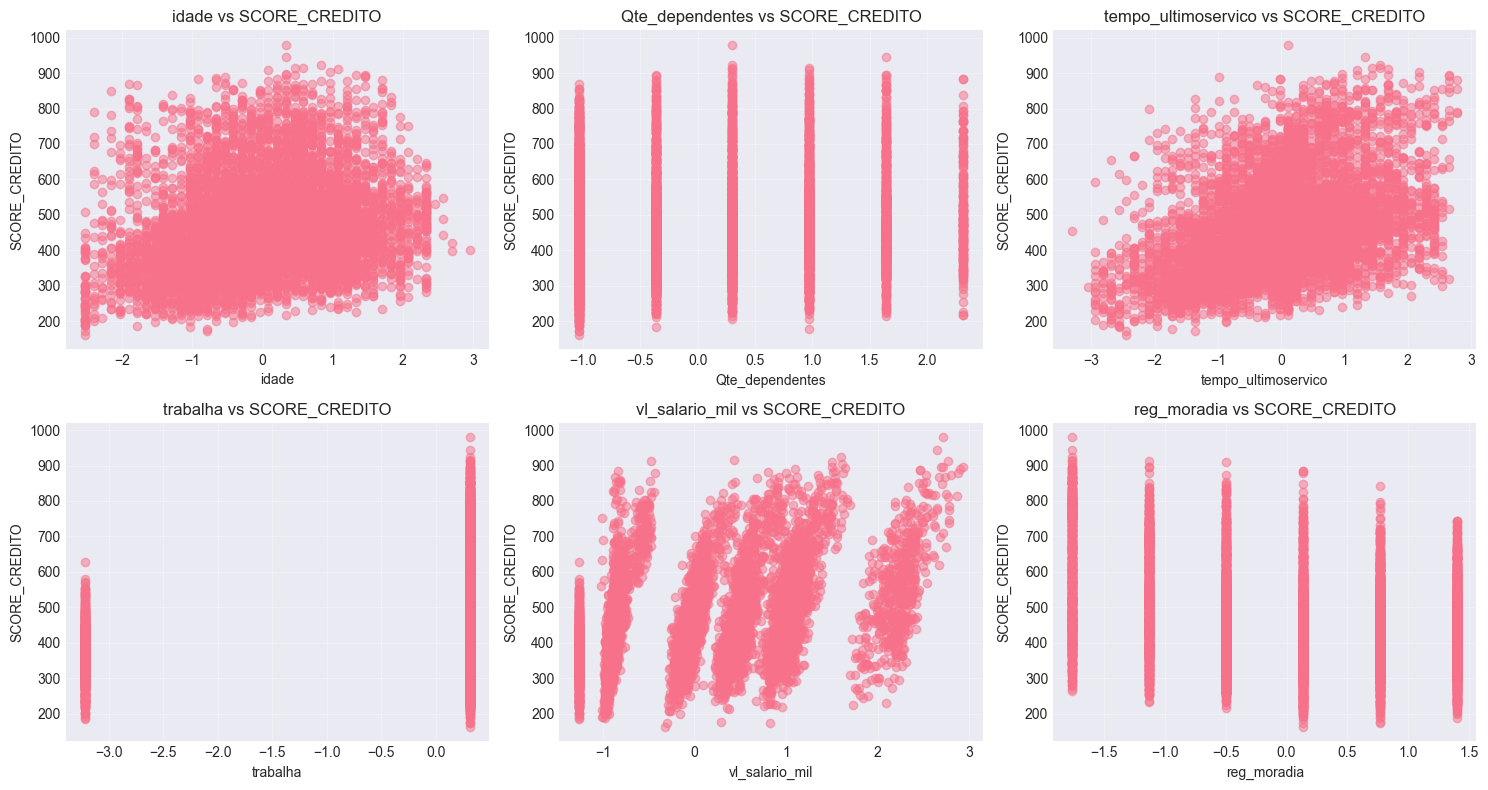

✓ Gráficos de dispersão criados para análise de linearidade


In [111]:
# 1. LINEARIDADE: Scatter plots de variáveis vs. target
print("VALIDAÇÃO DAS SUPOSIÇÕES DO MODELO")
print("="*80)
print("\n1. LINEARIDADE")
print("-"*80)

# Selecionar algumas variáveis numéricas principais para análise
vars_principais = variaveis_numericas[:6] if len(variaveis_numericas) >= 6 else variaveis_numericas

n_vars = len(vars_principais)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for idx, var in enumerate(vars_principais):
    if var in X_train.columns:
        axes[idx].scatter(X_train[var], y_train, alpha=0.5)
        axes[idx].set_xlabel(var)
        axes[idx].set_ylabel('SCORE_CREDITO')
        axes[idx].set_title(f'{var} vs SCORE_CREDITO')
        axes[idx].grid(True, alpha=0.3)

# Remover subplots vazios
for idx in range(n_vars, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()
print("✓ Gráficos de dispersão criados para análise de linearidade")



1. LINEARIDADE - Valores Originais (Detransformados)
--------------------------------------------------------------------------------
Visualização usando valores originais antes da padronização


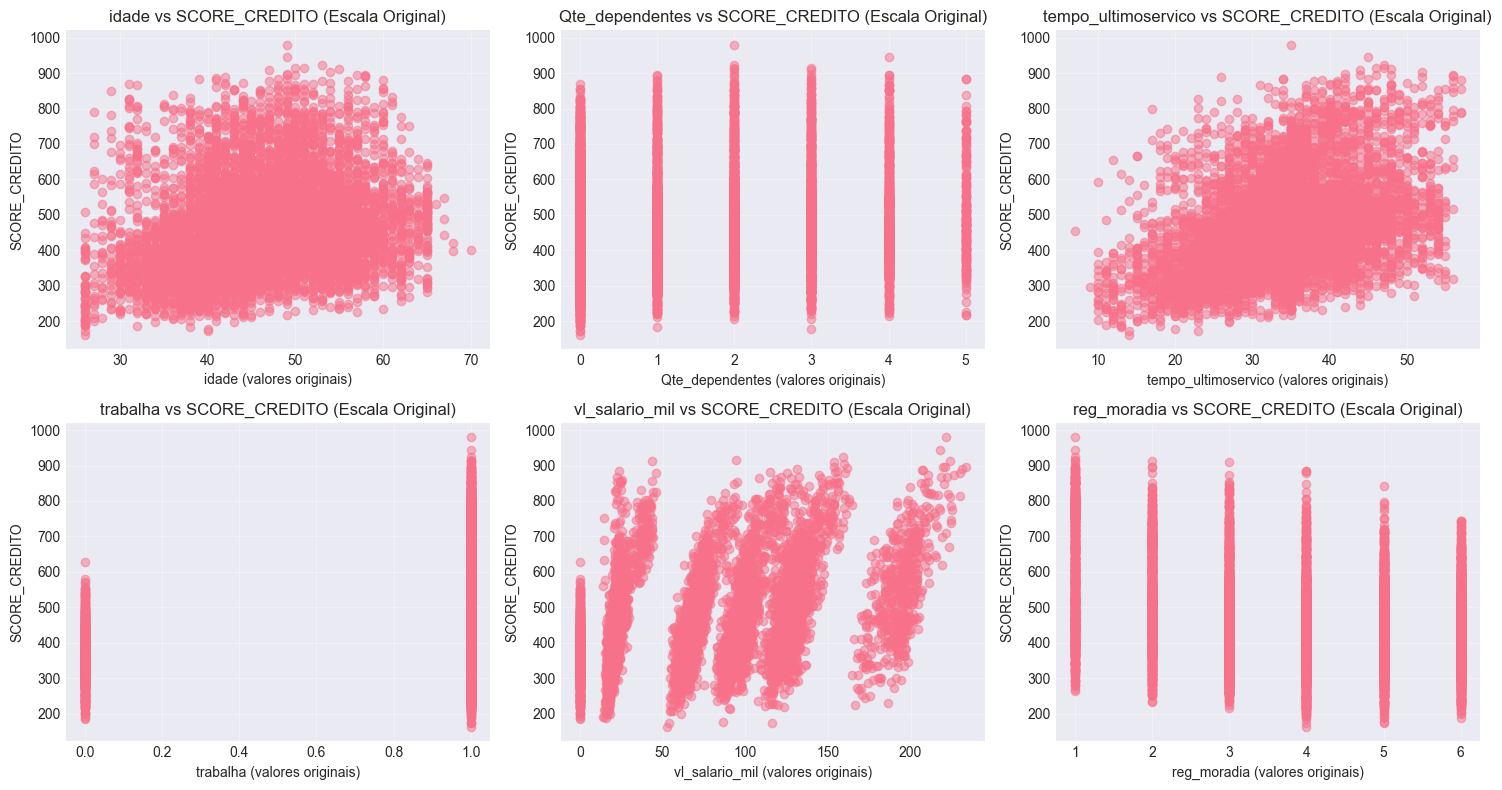

✓ Gráficos de dispersão criados com valores originais (detransformados)


In [134]:
# 1. LINEARIDADE: Scatter plots com valores originais (detransformados)
print("\n1. LINEARIDADE - Valores Originais (Detransformados)")
print("-"*80)
print("Visualização usando valores originais antes da padronização")

# Obter valores originais do conjunto de treino usando os índices
train_indices = X_train.index
y_train_original = df_processed.loc[train_indices, 'SCORE_CREDITO']

# Criar scatterplots com valores originais
n_vars = len(vars_principais)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for idx, var in enumerate(vars_principais):
    if var in df_processed.columns:
        # Usar valores originais da variável
        var_original = df_processed.loc[train_indices, var]
        axes[idx].scatter(var_original, y_train_original, alpha=0.5)
        axes[idx].set_xlabel(f'{var} (valores originais)')
        axes[idx].set_ylabel('SCORE_CREDITO')
        axes[idx].set_title(f'{var} vs SCORE_CREDITO (Escala Original)')
        axes[idx].grid(True, alpha=0.3)

# Remover subplots vazios
for idx in range(n_vars, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()
print("✓ Gráficos de dispersão criados com valores originais (detransformados)")


In [112]:
# 2. AUSÊNCIA DE MULTICOLINEARIDADE: VIF (Variance Inflation Factor)
print("\n2. AUSÊNCIA DE MULTICOLINEARIDADE (VIF)")
print("-"*80)

# Calcular VIF apenas para variáveis numéricas originais (antes do encoding)
# VIF não faz sentido para variáveis dummy de One-Hot Encoding
vars_numericas_originais = [v for v in variaveis_numericas if v in X_train_final.columns and v != 'SCORE_CREDITO']

if len(vars_numericas_originais) > 0:
    vif_data = pd.DataFrame()
    vif_data["Variável"] = vars_numericas_originais
    vif_data["VIF"] = [variance_inflation_factor(X_train_final[vars_numericas_originais].values, i) 
                       for i in range(len(vars_numericas_originais))]
    
    print("\nVIF (Variance Inflation Factor):")
    print("Regra geral: VIF > 10 indica multicolinearidade problemática")
    print("VIF > 5 pode indicar multicolinearidade moderada")
    print("\n" + vif_data.to_string(index=False))
    
    vif_alto = vif_data[vif_data['VIF'] > 10]
    if len(vif_alto) > 0:
        print(f"\n⚠ Atenção: {len(vif_alto)} variável(is) com VIF > 10:")
        print(vif_alto.to_string(index=False))
    else:
        print("\n✓ Nenhuma variável com VIF > 10 (multicolinearidade não problemática)")
else:
    print("Não há variáveis numéricas originais para calcular VIF")



2. AUSÊNCIA DE MULTICOLINEARIDADE (VIF)
--------------------------------------------------------------------------------

VIF (Variance Inflation Factor):
Regra geral: VIF > 10 indica multicolinearidade problemática
VIF > 5 pode indicar multicolinearidade moderada

           Variável      VIF
              idade 2.595665
    Qte_dependentes 1.104439
tempo_ultimoservico 2.606333
           trabalha 1.188701
     vl_salario_mil 1.239956
        reg_moradia 2.958823
       casa_propria 3.670308
   vl_imovel_em_mil 2.584235
        Qte_cartoes 1.048997
         Qte_carros 1.043814

✓ Nenhuma variável com VIF > 10 (multicolinearidade não problemática)


## 6. ANÁLISE DE RESÍDUOS

### 6.1 Diagnóstico dos Resíduos


In [113]:
# Calcular resíduos do modelo final
y_train_pred = modelo_final.predict(X_train_final)
y_test_pred = modelo_final.predict(X_test_final)

residuos_train = y_train - y_train_pred
residuos_test = y_test - y_test_pred

print("ANÁLISE DE RESÍDUOS")
print("="*80)
print(f"\nEstatísticas dos resíduos (Treino):")
print(f"  Média: {residuos_train.mean():.4f}")
print(f"  Desvio Padrão: {residuos_train.std():.4f}")
print(f"  Mínimo: {residuos_train.min():.4f}")
print(f"  Máximo: {residuos_train.max():.4f}")


ANÁLISE DE RESÍDUOS

Estatísticas dos resíduos (Treino):
  Média: -0.0000
  Desvio Padrão: 76.5292
  Mínimo: -230.9180
  Máximo: 402.5098


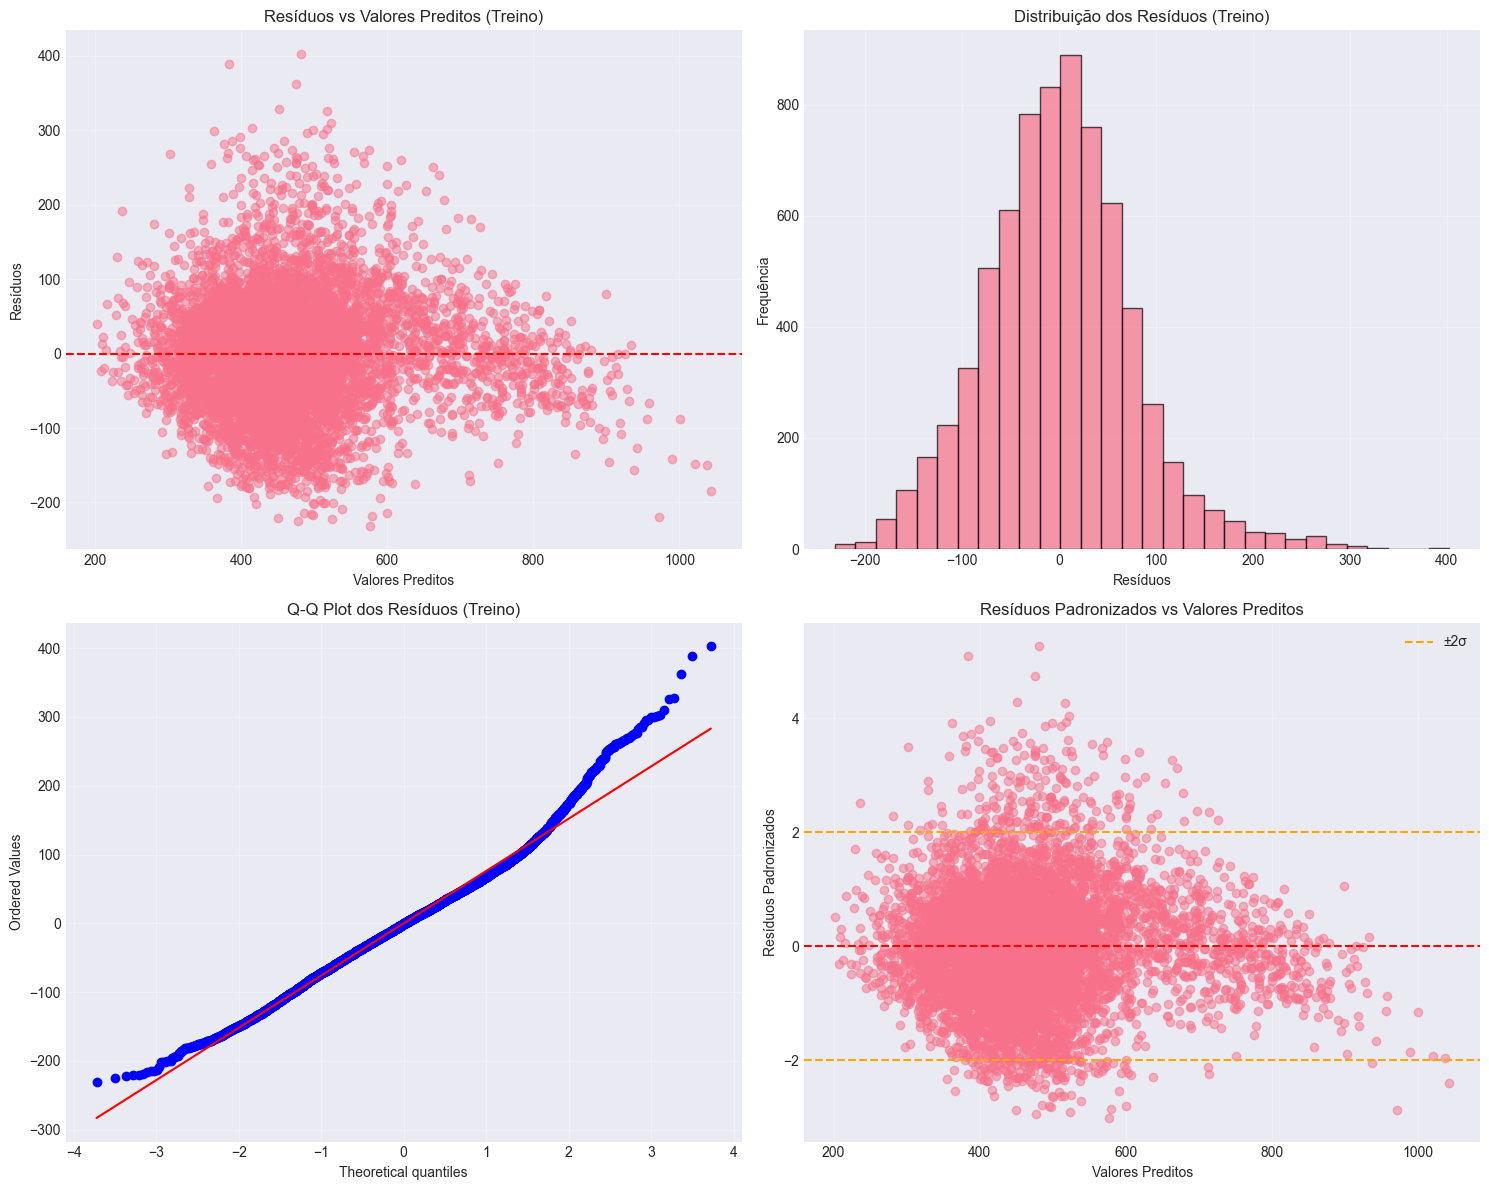

In [114]:
# Gráficos de diagnóstico dos resíduos
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Resíduos vs Valores Preditos
axes[0, 0].scatter(y_train_pred, residuos_train, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Valores Preditos')
axes[0, 0].set_ylabel('Resíduos')
axes[0, 0].set_title('Resíduos vs Valores Preditos (Treino)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histograma dos Resíduos
axes[0, 1].hist(residuos_train, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Resíduos')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].set_title('Distribuição dos Resíduos (Treino)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q Plot para normalidade
from scipy.stats import probplot
probplot(residuos_train, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot dos Resíduos (Treino)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Resíduos padronizados vs Valores Preditos
residuos_padronizados = residuos_train / residuos_train.std()
axes[1, 1].scatter(y_train_pred, residuos_padronizados, alpha=0.5)
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].axhline(y=2, color='orange', linestyle='--', label='±2σ')
axes[1, 1].axhline(y=-2, color='orange', linestyle='--')
axes[1, 1].set_xlabel('Valores Preditos')
axes[1, 1].set_ylabel('Resíduos Padronizados')
axes[1, 1].set_title('Resíduos Padronizados vs Valores Preditos')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 6.2 Testes Estatísticos


In [115]:
# Testes estatísticos para validação das suposições
print("TESTES ESTATÍSTICOS PARA VALIDAÇÃO DAS SUPOSIÇÕES")
print("="*80)

# 1. Teste de Normalidade dos Resíduos (Shapiro-Wilk)
print("\n1. TESTE DE NORMALIDADE DOS RESÍDUOS (Shapiro-Wilk)")
print("-"*80)
stat_shapiro, p_shapiro = shapiro(residuos_train.sample(min(5000, len(residuos_train))))
print(f"Estatística: {stat_shapiro:.4f}")
print(f"p-valor: {p_shapiro:.6f}")
if p_shapiro > 0.05:
    print("✓ Não rejeitamos H₀: Resíduos seguem distribuição normal (p > 0.05)")
else:
    print("✗ Rejeitamos H₀: Resíduos NÃO seguem distribuição normal (p ≤ 0.05)")
    print("  Atenção: Violação da suposição de normalidade")


TESTES ESTATÍSTICOS PARA VALIDAÇÃO DAS SUPOSIÇÕES

1. TESTE DE NORMALIDADE DOS RESÍDUOS (Shapiro-Wilk)
--------------------------------------------------------------------------------
Estatística: 0.9892
p-valor: 0.000000
✗ Rejeitamos H₀: Resíduos NÃO seguem distribuição normal (p ≤ 0.05)
  Atenção: Violação da suposição de normalidade


In [116]:
# 2. Teste de Homocedasticidade (Breusch-Pagan)
print("\n2. TESTE DE HOMOCEDASTICIDADE (Breusch-Pagan)")
print("-"*80)

if het_breuschpagan is not None:
    try:
        bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuos_train, X_train_final)
        print(f"Estatística: {bp_stat:.4f}")
        print(f"p-valor: {bp_pvalue:.6f}")
        if bp_pvalue > 0.05:
            print("✓ Não rejeitamos H₀: Homocedasticidade presente (p > 0.05)")
        else:
            print("✗ Rejeitamos H₀: Heterocedasticidade presente (p ≤ 0.05)")
            print("  Atenção: Violação da suposição de homocedasticidade")
    except Exception as e:
        print(f"Erro ao executar teste: {e}")
else:
    print("Função het_breuschpagan não disponível nesta versão do statsmodels")



2. TESTE DE HOMOCEDASTICIDADE (Breusch-Pagan)
--------------------------------------------------------------------------------
Estatística: 568.3030
p-valor: 0.000000
✗ Rejeitamos H₀: Heterocedasticidade presente (p ≤ 0.05)
  Atenção: Violação da suposição de homocedasticidade


In [117]:
# 3. Teste de Autocorrelação (Durbin-Watson)
print("\n3. TESTE DE AUTOCORRELAÇÃO (Durbin-Watson)")
print("-"*80)

if durbin_watson is not None:
    try:
        dw_stat = durbin_watson(residuos_train)
        print(f"Estatística Durbin-Watson: {dw_stat:.4f}")
        print("\nInterpretação:")
        print("  DW ≈ 2: Sem autocorrelação")
        print("  DW < 1.5: Autocorrelação positiva possível")
        print("  DW > 2.5: Autocorrelação negativa possível")
        
        if 1.5 < dw_stat < 2.5:
            print(f"\n✓ Estatística DW = {dw_stat:.4f}: Sem evidência de autocorrelação")
        else:
            print(f"\n⚠ Estatística DW = {dw_stat:.4f}: Possível autocorrelação")
    except Exception as e:
        print(f"Erro ao executar teste: {e}")
else:
    print("Função durbin_watson não disponível nesta versão do statsmodels")



3. TESTE DE AUTOCORRELAÇÃO (Durbin-Watson)
--------------------------------------------------------------------------------
Estatística Durbin-Watson: 1.9682

Interpretação:
  DW ≈ 2: Sem autocorrelação
  DW < 1.5: Autocorrelação positiva possível
  DW > 2.5: Autocorrelação negativa possível

✓ Estatística DW = 1.9682: Sem evidência de autocorrelação


## 7. MÉTRICAS DE AVALIAÇÃO

### 7.1 Métricas de Regressão


In [118]:
# Calcular métricas de regressão
print("MÉTRICAS DE AVALIAÇÃO DO MODELO")
print("="*80)

# Métricas para conjunto de treino
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

# Métricas para conjunto de teste
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

# R² Ajustado (do modelo statsmodels)
r2_adj_train = modelo_final.rsquared_adj

# Criar DataFrame com métricas
metricas = pd.DataFrame({
    'Métrica': ['MAE', 'MSE', 'RMSE', 'R²', 'R² Ajustado'],
    'Treino': [mae_train, mse_train, rmse_train, r2_train, r2_adj_train],
    'Teste': [mae_test, mse_test, rmse_test, r2_test, np.nan]
})

print("\nMétricas de Regressão:")
print(metricas.to_string(index=False))

print("\nInterpretação:")
print(f"  MAE: Erro médio absoluto de {mae_test:.2f} pontos no conjunto de teste")
print(f"  RMSE: Erro quadrático médio de {rmse_test:.2f} pontos no conjunto de teste")
print(f"  R²: O modelo explica {r2_test*100:.2f}% da variância do score de crédito")


MÉTRICAS DE AVALIAÇÃO DO MODELO

Métricas de Regressão:
    Métrica      Treino       Teste
        MAE   58.651602   62.279372
        MSE 5855.893452 6738.729680
       RMSE   76.523810   82.089766
         R²    0.672788    0.624034
R² Ajustado    0.672002         NaN

Interpretação:
  MAE: Erro médio absoluto de 62.28 pontos no conjunto de teste
  RMSE: Erro quadrático médio de 82.09 pontos no conjunto de teste
  R²: O modelo explica 62.40% da variância do score de crédito


### 7.2 Análise de Performance


In [119]:
# Análise de overfitting/underfitting
print("ANÁLISE DE PERFORMANCE")
print("="*80)

diferenca_r2 = r2_train - r2_test
diferenca_rmse = rmse_test - rmse_train

print(f"\nComparação Treino vs Teste:")
print(f"  Diferença R²: {diferenca_r2:.4f}")
print(f"  Diferença RMSE: {diferenca_rmse:.4f}")

if diferenca_r2 > 0.1:
    print("\n⚠ Possível OVERFITTING detectado:")
    print("  O modelo se ajustou muito bem aos dados de treino mas")
    print("  não generaliza bem para dados novos.")
elif diferenca_r2 < -0.05:
    print("\n⚠ Possível UNDERFITTING detectado:")
    print("  O modelo não está capturando padrões suficientes dos dados.")
else:
    print("\n✓ Modelo com bom equilíbrio entre treino e teste")
    print("  O modelo generaliza bem para dados novos.")


ANÁLISE DE PERFORMANCE

Comparação Treino vs Teste:
  Diferença R²: 0.0488
  Diferença RMSE: 5.5660

✓ Modelo com bom equilíbrio entre treino e teste
  O modelo generaliza bem para dados novos.


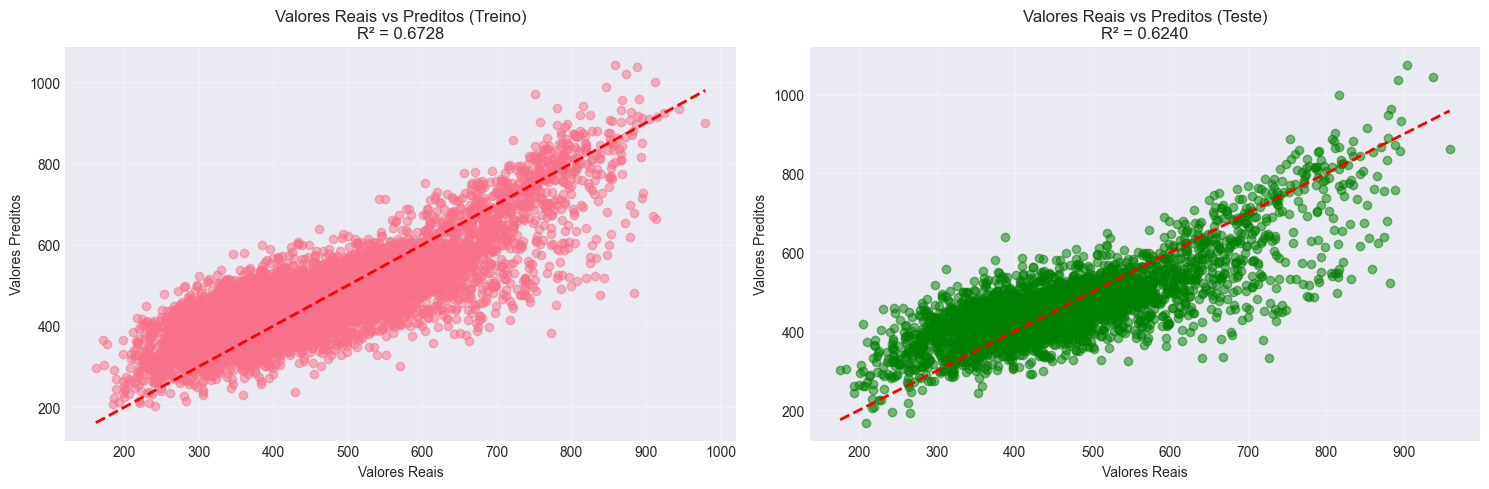

In [120]:
# Gráfico de Valores Reais vs Preditos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Treino
axes[0].scatter(y_train, y_train_pred, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Valores Reais')
axes[0].set_ylabel('Valores Preditos')
axes[0].set_title(f'Valores Reais vs Preditos (Treino)\nR² = {r2_train:.4f}')
axes[0].grid(True, alpha=0.3)

# Teste
axes[1].scatter(y_test, y_test_pred, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Valores Reais')
axes[1].set_ylabel('Valores Preditos')
axes[1].set_title(f'Valores Reais vs Preditos (Teste)\nR² = {r2_test:.4f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 7.3 Validação Cruzada


In [121]:
# Validação Cruzada k-fold (k=5)
print("VALIDAÇÃO CRUZADA (k-fold, k=5)")
print("="*80)

# Usar sklearn LinearRegression para validação cruzada
lr_cv = LinearRegression()
kfold = KFold(n_splits=5, shuffle=True, random_state=random_state)

# Calcular R² para cada fold
cv_scores_r2 = cross_val_score(lr_cv, X_train[features_finais], y_train, 
                                cv=kfold, scoring='r2', n_jobs=-1)

# Calcular RMSE para cada fold (usando neg_mean_squared_error e depois tirar raiz)
cv_scores_mse = -cross_val_score(lr_cv, X_train[features_finais], y_train, 
                                  cv=kfold, scoring='neg_mean_squared_error', n_jobs=-1)
cv_scores_rmse = np.sqrt(cv_scores_mse)

print(f"\nR² por fold:")
for i, score in enumerate(cv_scores_r2, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nRMSE por fold:")
for i, score in enumerate(cv_scores_rmse, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nEstatísticas da Validação Cruzada:")
print(f"  R² - Média: {cv_scores_r2.mean():.4f} ± {cv_scores_r2.std():.4f}")
print(f"  RMSE - Média: {cv_scores_rmse.mean():.4f} ± {cv_scores_rmse.std():.4f}")

if cv_scores_r2.std() < 0.05:
    print("\n✓ Modelo estável (baixa variância entre folds)")
else:
    print("\n⚠ Modelo com variabilidade entre folds (considerar ajustes)")


VALIDAÇÃO CRUZADA (k-fold, k=5)

R² por fold:
  Fold 1: 0.6660
  Fold 2: 0.6705
  Fold 3: 0.6817
  Fold 4: 0.6554
  Fold 5: 0.6762

RMSE por fold:
  Fold 1: 75.7991
  Fold 2: 76.1156
  Fold 3: 79.5354
  Fold 4: 77.4768
  Fold 5: 74.9434

Estatísticas da Validação Cruzada:
  R² - Média: 0.6700 ± 0.0090
  RMSE - Média: 76.7741 ± 1.6034

✓ Modelo estável (baixa variância entre folds)


## 8. INTERPRETAÇÃO E CONCLUSÕES

### 8.1 Interpretação dos Coeficientes


In [122]:
# Interpretação dos coeficientes do modelo final
print("INTERPRETAÇÃO DOS COEFICIENTES")
print("="*80)

coef_summary_final = modelo_final.summary2().tables[1]
coef_significativos_final = coef_summary_final[coef_summary_final['P>|t|'] < 0.05].copy()
coef_significativos_final = coef_significativos_final.sort_values('Coef.', key=abs, ascending=False)

print(f"\nVariáveis mais importantes (ordenadas por magnitude do coeficiente):")
print(f"Número de variáveis significativas: {len(coef_significativos_final)}")

for idx, row in coef_significativos_final.iterrows():
    if idx != 'const':
        coef = row['Coef.']
        impacto = "positivo" if coef > 0 else "negativo"
        print(f"\n{idx}:")
        print(f"  Coeficiente: {coef:.4f} (impacto {impacto})")
        print(f"  p-valor: {row['P>|t|']:.6f}")
        if abs(coef) > 0.1:
            print(f"  → Impacto significativo no score de crédito")
        else:
            print(f"  → Impacto moderado no score de crédito")


INTERPRETAÇÃO DOS COEFICIENTES

Variáveis mais importantes (ordenadas por magnitude do coeficiente):
Número de variáveis significativas: 14

vl_imovel_em_mil:
  Coeficiente: 86.0842 (impacto positivo)
  p-valor: 0.000000
  → Impacto significativo no score de crédito

casa_propria:
  Coeficiente: -51.6937 (impacto negativo)
  p-valor: 0.000000
  → Impacto significativo no score de crédito

tempo_ultimoservico:
  Coeficiente: 47.5194 (impacto positivo)
  p-valor: 0.000000
  → Impacto significativo no score de crédito

vl_salario_mil:
  Coeficiente: 38.2325 (impacto positivo)
  p-valor: 0.000000
  → Impacto significativo no score de crédito

Qte_carros:
  Coeficiente: 34.1200 (impacto positivo)
  p-valor: 0.000000
  → Impacto significativo no score de crédito

Qte_cartoes:
  Coeficiente: 23.4696 (impacto positivo)
  p-valor: 0.000000
  → Impacto significativo no score de crédito

estado_civil_divorciado:
  Coeficiente: 19.3975 (impacto positivo)
  p-valor: 0.000000
  → Impacto significati

In [123]:
# Top 10 variáveis mais importantes
print("\n" + "="*80)
print("TOP 10 VARIÁVEIS MAIS IMPORTANTES")
print("="*80)

top_10 = coef_significativos_final.head(10) if len(coef_significativos_final) >= 10 else coef_significativos_final

for i, (idx, row) in enumerate(top_10.iterrows(), 1):
    if idx != 'const':
        print(f"\n{i}. {idx}")
        print(f"   Coeficiente: {row['Coef.']:.4f}")
        print(f"   Significância: {'***' if row['P>|t|'] < 0.001 else '**' if row['P>|t|'] < 0.01 else '*'}")
        print(f"   Impacto: {'Aumenta' if row['Coef.'] > 0 else 'Diminui'} o score de crédito")



TOP 10 VARIÁVEIS MAIS IMPORTANTES

2. vl_imovel_em_mil
   Coeficiente: 86.0842
   Significância: ***
   Impacto: Aumenta o score de crédito

3. casa_propria
   Coeficiente: -51.6937
   Significância: ***
   Impacto: Diminui o score de crédito

4. tempo_ultimoservico
   Coeficiente: 47.5194
   Significância: ***
   Impacto: Aumenta o score de crédito

5. vl_salario_mil
   Coeficiente: 38.2325
   Significância: ***
   Impacto: Aumenta o score de crédito

6. Qte_carros
   Coeficiente: 34.1200
   Significância: ***
   Impacto: Aumenta o score de crédito

7. Qte_cartoes
   Coeficiente: 23.4696
   Significância: ***
   Impacto: Aumenta o score de crédito

8. estado_civil_divorciado
   Coeficiente: 19.3975
   Significância: ***
   Impacto: Aumenta o score de crédito

9. sexo_M
   Coeficiente: -17.0787
   Significância: ***
   Impacto: Diminui o score de crédito

10. reg_moradia
   Coeficiente: -12.6163
   Significância: ***
   Impacto: Diminui o score de crédito


## 9. ANÁLISE COMPARATIVA: MODELOS SEPARADOS POR POSSE DE CASA PRÓPRIA

### 9.1 Estratégia: Dois Modelos Especializados


In [124]:
# Análise comparativa: Modelos separados por posse de casa própria
# Estratégia: Criar dois modelos especializados e comparar com modelo único

print("ANÁLISE COMPARATIVA: MODELOS SEPARADOS POR POSSE DE CASA PRÓPRIA")
print("="*80)
print("\nEstratégia:")
print("  1. Modelo para pessoas COM casa própria (casa_propria == 1)")
print("  2. Modelo para pessoas SEM casa própria (casa_propria == 0)")
print("  3. Comparação com modelo único atual")

# Verificar distribuição de casa_propria nos conjuntos de treino e teste
print("\n" + "="*80)
print("DISTRIBUIÇÃO DOS DADOS")
print("="*80)

# Usar dados originais (antes da padronização) para identificar casa_propria
# Mas precisamos usar os dados processados para treinar
# Vamos usar df_final que tem os dados processados, mas precisamos identificar casa_propria

# Identificar índices de casa_propria no conjunto de treino e teste
# Como casa_propria foi padronizada, precisamos identificar pelos índices originais
train_indices = X_train.index
test_indices = X_test.index

# Recuperar valores originais de casa_propria do df_processed
casa_propria_train = df_processed.loc[train_indices, 'casa_propria']
casa_propria_test = df_processed.loc[test_indices, 'casa_propria']

print(f"\nConjunto de Treino:")
print(f"  Com casa própria: {sum(casa_propria_train == 1)} ({sum(casa_propria_train == 1)/len(casa_propria_train)*100:.2f}%)")
print(f"  Sem casa própria: {sum(casa_propria_train == 0)} ({sum(casa_propria_train == 0)/len(casa_propria_train)*100:.2f}%)")

print(f"\nConjunto de Teste:")
print(f"  Com casa própria: {sum(casa_propria_test == 1)} ({sum(casa_propria_test == 1)/len(casa_propria_test)*100:.2f}%)")
print(f"  Sem casa própria: {sum(casa_propria_test == 0)} ({sum(casa_propria_test == 0)/len(casa_propria_test)*100:.2f}%)")


ANÁLISE COMPARATIVA: MODELOS SEPARADOS POR POSSE DE CASA PRÓPRIA

Estratégia:
  1. Modelo para pessoas COM casa própria (casa_propria == 1)
  2. Modelo para pessoas SEM casa própria (casa_propria == 0)
  3. Comparação com modelo único atual

DISTRIBUIÇÃO DOS DADOS

Conjunto de Treino:
  Com casa própria: 2504 (35.33%)
  Sem casa própria: 4584 (64.67%)

Conjunto de Teste:
  Com casa própria: 1065 (35.04%)
  Sem casa própria: 1974 (64.96%)


### 9.2 Construção dos Modelos Especializados


In [125]:
# Separar dados de treino por casa_propria
mask_com_casa_train = casa_propria_train == 1
mask_sem_casa_train = casa_propria_train == 0

X_train_com_casa = X_train[mask_com_casa_train]
y_train_com_casa = y_train[mask_com_casa_train]

X_train_sem_casa = X_train[mask_sem_casa_train]
y_train_sem_casa = y_train[mask_sem_casa_train]

print("CONSTRUÇÃO DOS MODELOS ESPECIALIZADOS")
print("="*80)

# Remover casa_propria das features (já que estamos separando por ela)
# Mas primeiro vamos verificar se ela está nas features
features_sem_casa_propria = [f for f in features_finais if f != 'casa_propria']

print(f"\nFeatures utilizadas (sem casa_propria): {len(features_sem_casa_propria)}")
print(f"Features: {features_sem_casa_propria}")

# Modelo 1: Para pessoas COM casa própria
print("\n" + "-"*80)
print("MODELO 1: Pessoas COM casa própria")
print("-"*80)

X_train_com_casa_final = X_train_com_casa[features_sem_casa_propria]
X_train_com_casa_const = sm.add_constant(X_train_com_casa_final)

modelo_com_casa = sm.OLS(y_train_com_casa, X_train_com_casa_const).fit()

print(f"Tamanho do conjunto de treino: {len(X_train_com_casa_final)}")
print(f"R²: {modelo_com_casa.rsquared:.4f}")
print(f"R² Ajustado: {modelo_com_casa.rsquared_adj:.4f}")
print(f"AIC: {modelo_com_casa.aic:.2f}")

# Modelo 2: Para pessoas SEM casa própria
print("\n" + "-"*80)
print("MODELO 2: Pessoas SEM casa própria")
print("-"*80)

X_train_sem_casa_final = X_train_sem_casa[features_sem_casa_propria]
X_train_sem_casa_const = sm.add_constant(X_train_sem_casa_final)

modelo_sem_casa = sm.OLS(y_train_sem_casa, X_train_sem_casa_const).fit()

print(f"Tamanho do conjunto de treino: {len(X_train_sem_casa_final)}")
print(f"R²: {modelo_sem_casa.rsquared:.4f}")
print(f"R² Ajustado: {modelo_sem_casa.rsquared_adj:.4f}")
print(f"AIC: {modelo_sem_casa.aic:.2f}")


CONSTRUÇÃO DOS MODELOS ESPECIALIZADOS

Features utilizadas (sem casa_propria): 16
Features: ['idade', 'Qte_dependentes', 'tempo_ultimoservico', 'trabalha', 'vl_salario_mil', 'reg_moradia', 'vl_imovel_em_mil', 'Qte_cartoes', 'Qte_carros', 'sexo_M', 'estado_civil_divorciado', 'estado_civil_solteiro', 'escola_ensino fundam', 'escola_ensino medio', 'escola_graduacao', 'escola_mestrado']

--------------------------------------------------------------------------------
MODELO 1: Pessoas COM casa própria
--------------------------------------------------------------------------------
Tamanho do conjunto de treino: 2504
R²: 0.8395
R² Ajustado: 0.8385
AIC: 27722.66

--------------------------------------------------------------------------------
MODELO 2: Pessoas SEM casa própria
--------------------------------------------------------------------------------
Tamanho do conjunto de treino: 4584
R²: 0.4781
R² Ajustado: 0.4764
AIC: 53532.75


### 9.3 Predições com Modelos Especializados


In [126]:
# Fazer predições no conjunto de teste usando o modelo apropriado
print("PREDIÇÕES COM MODELOS ESPECIALIZADOS")
print("="*80)

# Separar dados de teste
mask_com_casa_test = casa_propria_test == 1
mask_sem_casa_test = casa_propria_test == 0

X_test_com_casa = X_test[mask_com_casa_test]
y_test_com_casa = y_test[mask_com_casa_test]

X_test_sem_casa = X_test[mask_sem_casa_test]
y_test_sem_casa = y_test[mask_sem_casa_test]

# Predições para cada grupo
X_test_com_casa_final = X_test_com_casa[features_sem_casa_propria]
X_test_com_casa_const = sm.add_constant(X_test_com_casa_final)
y_pred_com_casa = modelo_com_casa.predict(X_test_com_casa_const)

X_test_sem_casa_final = X_test_sem_casa[features_sem_casa_propria]
X_test_sem_casa_const = sm.add_constant(X_test_sem_casa_final)
y_pred_sem_casa = modelo_sem_casa.predict(X_test_sem_casa_const)

# Combinar predições
y_pred_combinado = np.zeros(len(y_test))
y_pred_combinado[mask_com_casa_test] = y_pred_com_casa
y_pred_combinado[mask_sem_casa_test] = y_pred_sem_casa

print(f"\nPredições realizadas:")
print(f"  Com casa própria: {len(y_pred_com_casa)} observações")
print(f"  Sem casa própria: {len(y_pred_sem_casa)} observações")
print(f"  Total: {len(y_pred_combinado)} observações")


PREDIÇÕES COM MODELOS ESPECIALIZADOS

Predições realizadas:
  Com casa própria: 1065 observações
  Sem casa própria: 1974 observações
  Total: 3039 observações


### 9.4 Comparação de Performance


In [127]:
# Comparar métricas entre modelo único e modelos especializados
print("COMPARAÇÃO DE PERFORMANCE")
print("="*80)

# Métricas do modelo único (atual)
mae_unico = mean_absolute_error(y_test, y_test_pred)
mse_unico = mean_squared_error(y_test, y_test_pred)
rmse_unico = np.sqrt(mse_unico)
r2_unico = r2_score(y_test, y_test_pred)

# Métricas dos modelos especializados combinados
mae_combinado = mean_absolute_error(y_test, y_pred_combinado)
mse_combinado = mean_squared_error(y_test, y_pred_combinado)
rmse_combinado = np.sqrt(mse_combinado)
r2_combinado = r2_score(y_test, y_pred_combinado)

# Métricas por grupo (modelos especializados)
mae_com_casa = mean_absolute_error(y_test_com_casa, y_pred_com_casa)
rmse_com_casa = np.sqrt(mean_squared_error(y_test_com_casa, y_pred_com_casa))
r2_com_casa = r2_score(y_test_com_casa, y_pred_com_casa)

mae_sem_casa = mean_absolute_error(y_test_sem_casa, y_pred_sem_casa)
rmse_sem_casa = np.sqrt(mean_squared_error(y_test_sem_casa, y_pred_sem_casa))
r2_sem_casa = r2_score(y_test_sem_casa, y_pred_sem_casa)

# Criar tabela comparativa
comparacao_modelos = pd.DataFrame({
    'Estratégia': [
        'Modelo Único (Atual)',
        'Modelos Especializados (Combinado)',
        '  └─ Com Casa Própria',
        '  └─ Sem Casa Própria'
    ],
    'MAE': [
        mae_unico,
        mae_combinado,
        mae_com_casa,
        mae_sem_casa
    ],
    'RMSE': [
        rmse_unico,
        rmse_combinado,
        rmse_com_casa,
        rmse_sem_casa
    ],
    'R²': [
        r2_unico,
        r2_combinado,
        r2_com_casa,
        r2_sem_casa
    ],
    'N': [
        len(y_test),
        len(y_test),
        len(y_test_com_casa),
        len(y_test_sem_casa)
    ]
})

print("\nComparação de Métricas:")
print(comparacao_modelos.to_string(index=False))

# Calcular melhorias
melhoria_mae = ((mae_unico - mae_combinado) / mae_unico) * 100
melhoria_rmse = ((rmse_unico - rmse_combinado) / rmse_unico) * 100
melhoria_r2 = ((r2_combinado - r2_unico) / abs(r2_unico)) * 100

print("\n" + "="*80)
print("ANÁLISE DE MELHORIA")
print("="*80)
print(f"\nMelhoria do Modelo Especializado vs Modelo Único:")
print(f"  MAE:  {melhoria_mae:+.2f}% ({'Melhor' if melhoria_mae > 0 else 'Pior'})")
print(f"  RMSE: {melhoria_rmse:+.2f}% ({'Melhor' if melhoria_rmse > 0 else 'Pior'})")
print(f"  R²:   {melhoria_r2:+.2f}% ({'Melhor' if melhoria_r2 > 0 else 'Pior'})")

if melhoria_r2 > 0:
    print("\n✓ Os modelos especializados apresentam MELHOR performance!")
    print("  A estratégia de separar por posse de casa própria é mais eficaz.")
elif melhoria_r2 < -1:
    print("\n✗ Os modelos especializados apresentam PIOR performance.")
    print("  O modelo único é mais eficaz para este caso.")
else:
    print("\n≈ Os modelos apresentam performance similar.")
    print("  A escolha pode depender de outros fatores (interpretabilidade, complexidade).")


COMPARAÇÃO DE PERFORMANCE

Comparação de Métricas:
                        Estratégia       MAE      RMSE       R²    N
              Modelo Único (Atual) 62.279372 82.089766 0.624034 3039
Modelos Especializados (Combinado) 61.747378 81.420971 0.630135 3039
               └─ Com Casa Própria 50.295027 64.627882 0.814812 1065
               └─ Sem Casa Própria 67.926078 89.177306 0.434247 1974

ANÁLISE DE MELHORIA

Melhoria do Modelo Especializado vs Modelo Único:
  MAE:  +0.85% (Melhor)
  RMSE: +0.81% (Melhor)
  R²:   +0.98% (Melhor)

✓ Os modelos especializados apresentam MELHOR performance!
  A estratégia de separar por posse de casa própria é mais eficaz.


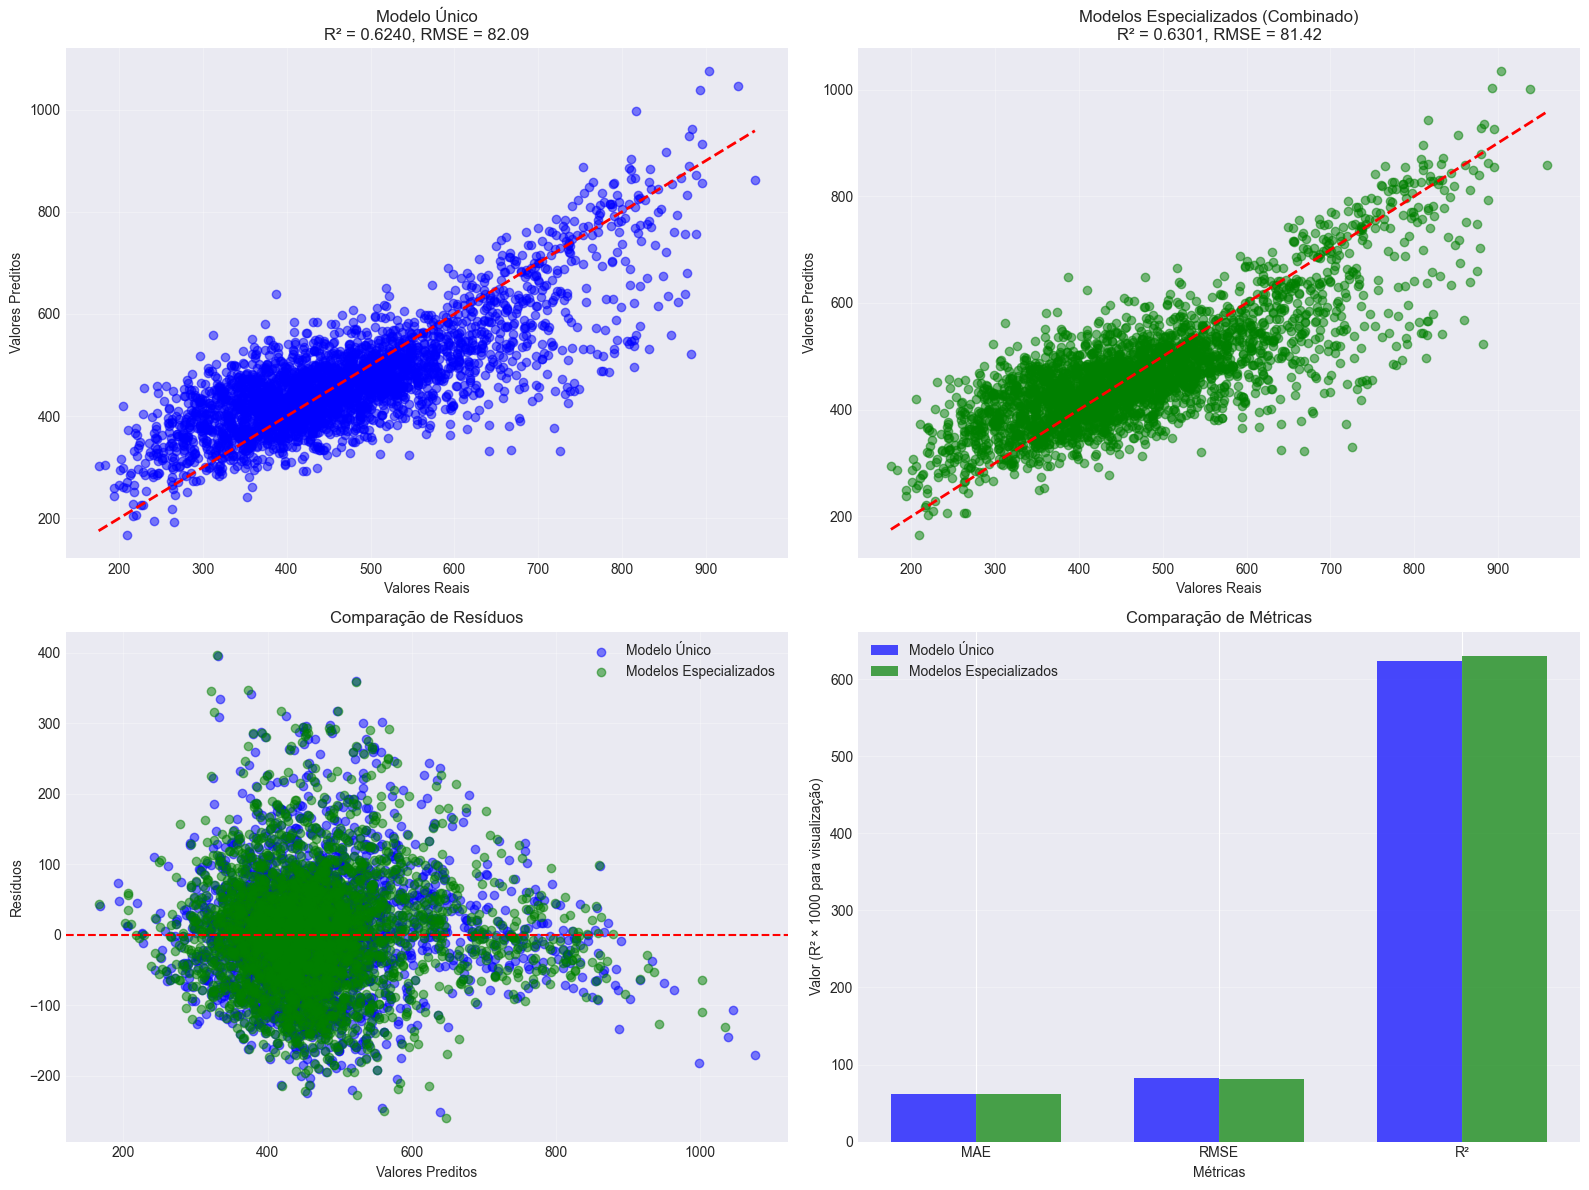

In [131]:
# Visualização comparativa
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Valores Reais vs Preditos - Modelo Único
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.5, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Valores Reais')
axes[0, 0].set_ylabel('Valores Preditos')
axes[0, 0].set_title(f'Modelo Único\nR² = {r2_unico:.4f}, RMSE = {rmse_unico:.2f}')
axes[0, 0].grid(True, alpha=0.3)

# 2. Valores Reais vs Preditos - Modelos Especializados (Combinado)
axes[0, 1].scatter(y_test, y_pred_combinado, alpha=0.5, color='green')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Valores Reais')
axes[0, 1].set_ylabel('Valores Preditos')
axes[0, 1].set_title(f'Modelos Especializados (Combinado)\nR² = {r2_combinado:.4f}, RMSE = {rmse_combinado:.2f}')
axes[0, 1].grid(True, alpha=0.3)

# 3. Comparação de Resíduos
residuos_unico = y_test - y_test_pred
residuos_combinado = y_test - y_pred_combinado

axes[1, 0].scatter(y_test_pred, residuos_unico, alpha=0.5, color='blue', label='Modelo Único')
axes[1, 0].scatter(y_pred_combinado, residuos_combinado, alpha=0.5, color='green', label='Modelos Especializados')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Valores Preditos')
axes[1, 0].set_ylabel('Resíduos')
axes[1, 0].set_title('Comparação de Resíduos')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Comparação de Métricas
metricas_comparacao = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'R²'],
    'Modelo Único': [mae_unico, rmse_unico, r2_unico],
    'Modelos Especializados': [mae_combinado, rmse_combinado, r2_combinado]
})

x = np.arange(len(metricas_comparacao))
width = 0.35

# Normalizar R² para visualização (multiplicar por 1000 para escala similar)
mae_norm = metricas_comparacao[metricas_comparacao['Métrica'] == 'MAE'].values
rmse_norm = metricas_comparacao[metricas_comparacao['Métrica'] == 'RMSE'].values
r2_norm = metricas_comparacao[metricas_comparacao['Métrica'] == 'R²'].values * 1000

axes[1, 1].bar(x - width/2, [mae_unico, rmse_unico, r2_unico*1000], width, 
               label='Modelo Único', color='blue', alpha=0.7)
axes[1, 1].bar(x + width/2, [mae_combinado, rmse_combinado, r2_combinado*1000], width,
               label='Modelos Especializados', color='green', alpha=0.7)
axes[1, 1].set_xlabel('Métricas')
axes[1, 1].set_ylabel('Valor (R² × 1000 para visualização)')
axes[1, 1].set_title('Comparação de Métricas')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(['MAE', 'RMSE', 'R²'])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### 9.5 Análise Detalhada por Grupo


In [132]:
# Análise detalhada da performance por grupo
print("ANÁLISE DETALHADA POR GRUPO")
print("="*80)

# Métricas do modelo único por grupo
y_test_pred_com_casa = y_test_pred[mask_com_casa_test]
y_test_pred_sem_casa = y_test_pred[mask_sem_casa_test]

mae_unico_com_casa = mean_absolute_error(y_test_com_casa, y_test_pred_com_casa)
rmse_unico_com_casa = np.sqrt(mean_squared_error(y_test_com_casa, y_test_pred_com_casa))
r2_unico_com_casa = r2_score(y_test_com_casa, y_test_pred_com_casa)

mae_unico_sem_casa = mean_absolute_error(y_test_sem_casa, y_test_pred_sem_casa)
rmse_unico_sem_casa = np.sqrt(mean_squared_error(y_test_sem_casa, y_test_pred_sem_casa))
r2_unico_sem_casa = r2_score(y_test_sem_casa, y_test_pred_sem_casa)

# Criar tabela comparativa por grupo
comparacao_por_grupo = pd.DataFrame({
    'Grupo': [
        'COM Casa Própria',
        'COM Casa Própria',
        'SEM Casa Própria',
        'SEM Casa Própria'
    ],
    'Estratégia': [
        'Modelo Único',
        'Modelo Especializado',
        'Modelo Único',
        'Modelo Especializado'
    ],
    'MAE': [
        mae_unico_com_casa,
        mae_com_casa,
        mae_unico_sem_casa,
        mae_sem_casa
    ],
    'RMSE': [
        rmse_unico_com_casa,
        rmse_com_casa,
        rmse_unico_sem_casa,
        rmse_sem_casa
    ],
    'R²': [
        r2_unico_com_casa,
        r2_com_casa,
        r2_unico_sem_casa,
        r2_sem_casa
    ]
})

print("\nComparação por Grupo:")
print(comparacao_por_grupo.to_string(index=False))

# Calcular melhorias por grupo
melhoria_com_casa_mae = ((mae_unico_com_casa - mae_com_casa) / mae_unico_com_casa) * 100
melhoria_com_casa_r2 = ((r2_com_casa - r2_unico_com_casa) / abs(r2_unico_com_casa)) * 100

melhoria_sem_casa_mae = ((mae_unico_sem_casa - mae_sem_casa) / mae_unico_sem_casa) * 100
melhoria_sem_casa_r2 = ((r2_sem_casa - r2_unico_sem_casa) / abs(r2_unico_sem_casa)) * 100

print("\n" + "="*80)
print("MELHORIAS POR GRUPO")
print("="*80)
print(f"\nGrupo COM Casa Própria:")
print(f"  Melhoria MAE: {melhoria_com_casa_mae:+.2f}%")
print(f"  Melhoria R²:  {melhoria_com_casa_r2:+.2f}%")

print(f"\nGrupo SEM Casa Própria:")
print(f"  Melhoria MAE: {melhoria_sem_casa_mae:+.2f}%")
print(f"  Melhoria R²:  {melhoria_sem_casa_r2:+.2f}%")


ANÁLISE DETALHADA POR GRUPO

Comparação por Grupo:
           Grupo           Estratégia       MAE      RMSE       R²
COM Casa Própria         Modelo Único 51.047878 65.957706 0.807113
COM Casa Própria Modelo Especializado 50.295027 64.627882 0.814812
SEM Casa Própria         Modelo Único 68.338916 89.594955 0.428935
SEM Casa Própria Modelo Especializado 67.926078 89.177306 0.434247

MELHORIAS POR GRUPO

Grupo COM Casa Própria:
  Melhoria MAE: +1.47%
  Melhoria R²:  +0.95%

Grupo SEM Casa Própria:
  Melhoria MAE: +0.60%
  Melhoria R²:  +1.24%


### 9.6 Conclusões da Análise Comparativa


In [133]:
# Resumo e conclusões
print("CONCLUSÕES DA ANÁLISE COMPARATIVA")
print("="*80)

print("\n1. RESUMO DAS ESTRATÉGIAS:")
print("-"*80)
print("  • Modelo Único: Um único modelo para todos os clientes")
print("  • Modelos Especializados: Dois modelos separados por posse de casa própria")

print("\n2. PERFORMANCE GERAL:")
print("-"*80)
if melhoria_r2 > 0:
    print(f"  ✓ Modelos Especializados são SUPERIORES")
    print(f"    Melhoria de R²: {melhoria_r2:.2f}%")
    print(f"    Redução de RMSE: {melhoria_rmse:.2f}%")
else:
    print(f"  ✗ Modelo Único é SUPERIOR ou EQUIVALENTE")
    print(f"    Diferença de R²: {melhoria_r2:.2f}%")

print("\n3. INTERPRETAÇÃO:")
print("-"*80)
if melhoria_r2 > 1:
    print("  • A separação por posse de casa própria captura padrões distintos")
    print("  • Os modelos especializados conseguem ajustar melhor às características")
    print("    específicas de cada grupo")
    print("  • RECOMENDAÇÃO: Adotar estratégia de modelos especializados")
elif melhoria_r2 < -1:
    print("  • O modelo único generaliza melhor para ambos os grupos")
    print("  • A separação não trouxe benefícios significativos")
    print("  • RECOMENDAÇÃO: Manter modelo único")
else:
    print("  • Ambas as estratégias apresentam performance similar")
    print("  • A escolha pode depender de:")
    print("    - Complexidade de implementação")
    print("    - Interpretabilidade dos modelos")
    print("    - Necessidades específicas do negócio")

print("\n4. CONSIDERAÇÕES FINAIS:")
print("-"*80)
print("  • Modelos especializados podem ser mais interpretáveis para cada segmento")
print("  • Modelo único é mais simples de manter e implementar")
print("  • A decisão final deve considerar o contexto de negócio e recursos disponíveis")


CONCLUSÕES DA ANÁLISE COMPARATIVA

1. RESUMO DAS ESTRATÉGIAS:
--------------------------------------------------------------------------------
  • Modelo Único: Um único modelo para todos os clientes
  • Modelos Especializados: Dois modelos separados por posse de casa própria

2. PERFORMANCE GERAL:
--------------------------------------------------------------------------------
  ✓ Modelos Especializados são SUPERIORES
    Melhoria de R²: 0.98%
    Redução de RMSE: 0.81%

3. INTERPRETAÇÃO:
--------------------------------------------------------------------------------
  • Ambas as estratégias apresentam performance similar
  • A escolha pode depender de:
    - Complexidade de implementação
    - Interpretabilidade dos modelos
    - Necessidades específicas do negócio

4. CONSIDERAÇÕES FINAIS:
--------------------------------------------------------------------------------
  • Modelos especializados podem ser mais interpretáveis para cada segmento
  • Modelo único é mais simples de man